In [360]:
import json

import numpy as np
import pandas as pd

import seaborn as sns

from matplotlib import pyplot as plt


In [361]:
non_dataset_exercises = ["Ab Crunch Machine","Leg Raises",
"Side Crunches",
"Ab Roll Outs",
"Preacher Curls",
"Mugura Extensions",
"Pull-ups",
"Krūtis Fly Machine",
"Krūtis Press Machine",
"Cable Krūtis Fly",
"Bulgarian Split Squat",
"Romanian Deadlifts",
"Stiff-Leg Deadlifts",
"Machine Deadlifts",
"Single Leg Romanian Deadlifts",]

In [714]:
EXERCISE_GROUPS = {
    "Ab Crunch Machine":        "Vēders",
    "Crunches":                 "Vēders",
    "Leg Raises":               "Vēders",
    "Plank":                    "Vēders",
    "Ab Roll Outs":             "Vēders",

    "Dumbbell Bicep Curls":     "Bicepsi",
    "Hammer Curls":             "Bicepsi",
    "Incline Dumbbell Curls":   "Bicepsi",
    "Preacher Curls":           "Bicepsi",
    "Tricep Pushdowns":         "Tricepsi",
    "Cable Overhead Extensions": "Tricepsi",
    "Dips":                     "Tricepsi",

    "Cable Rows":               "Mugura",
    "Lat Pulldowns":            "Mugura",
    "Row Machine":              "Mugura",
    "Straight Arm Lat Pulldowns": "Mugura",
    "Back Extensions":          "Mugura",
    "Pull-ups":                 "Mugura",

    "Bench Press":              "Krūtis",
    "Chest Fly Machine":        "Krūtis",
    "Chest Press Machine":      "Krūtis",
    "Dumbbell Bench Press":     "Krūtis",
    "Dumbell Chest Flys":       "Krūtis",
    "Cable Chest Fly":          "Krūtis",
    "Incline Dumbbell Bench Press": "Krūtis",

    "Barbell Squats":           "Kājas",
    "Bulgarian Split Squat":    "Kājas",
    "Goblet Squats":            "Kājas",
    "Lunges":                   "Kājas",
    "Romanian Deadlifts":       "Kājas",
    "Stiff-Leg Deadlifts":      "Kājas",
    "Machine Deadlifts":        "Kājas",
    "Single Leg Romanian Deadlifts": "Kājas",

    "Dumbbell Lateral Raises":  "Pleci",
    "Dumbbell Overhead Press":  "Pleci",
    "Machine Lateral Raises":   "Pleci",
    "Cable Lateral Raises":     "Pleci",

}

GROUP_ORDER = ["Vēders", "Bicepsi", "Tricepsi", "Mugura", "Krūtis", "Kājas", "Pleci"]

# Load methods

In [372]:
def load_sessions(session_paths, ignore_list=None):
    ignore_list = ignore_list or []

    all_session_windows = []
    all_session_events = []
    all_info = []

    session_id = 1

    for path in session_paths:
        accel, gyro, clf, annotations, info = load_recording(path)

        events_watch_time = convert_events_to_watch_time(
            annotations,
            info
        )

        clf, events = remove_ignored_exercises(
            clf,
            events_watch_time,
            ignore_list=ignore_list
        )

        for event in events:
            event["group"] = EXERCISE_GROUPS.get(event["name"], "Unknown")
            event["session"] = path
            event["session_id"] = session_id

        clf = add_ground_truth(clf, events)
        clf["session"] = path
        clf["session_id"] = session_id

        session_id += 1

        all_session_windows.append(clf)
        all_session_events.extend(events)
        all_info.append(info)

    return all_session_windows, all_session_events, all_info

def load_recording(path):
    accel = pd.read_csv(f"{path}/accel.csv")
    gyro = pd.read_csv(f"{path}/gyro.csv")
    classification = pd.read_csv(f"{path}/classification.csv")

    # Parse serialized IMU windows
    classification["window_data"] = classification["window_data"].apply(parse_window_data)

    with open(f"{path}/annotations.json") as f:
        annotations = json.load(f)

    with open(f"{path}/info.txt") as f:
        lines = f.read().splitlines()

    info = {
        "watch_start_timestamp": int(lines[0].split("=")[1]),
        "watch_end_timestamp": int(lines[2].split("=")[1]),
    }

    return accel, gyro, classification, annotations, info

def parse_window_data(window_str, expected_channels=6):
    """
    Converts one serialized window string into a NumPy array.

    Input format:
    'a1|a2|a3|g1|g2|g3;a1|a2|a3|g1|g2|g3;...'

    Output shape:
    (window_length, 6)
    """
    if pd.isna(window_str):
        raise ValueError("window_data is missing")

    rows = [row for row in window_str.strip().split(";") if row.strip()]

    window = []
    for row in rows:
        values = [float(value) for value in row.split("|")]

        if len(values) != expected_channels:
            raise ValueError(f"Expected {expected_channels} channels, got {len(values)}")

        window.append(values)

    return np.array(window, dtype=np.float32)

def convert_events_to_watch_time(annotations, info, linear=False):
    phone_start = annotations["phoneStartTimestamp"]
    phone_end = annotations["phoneEndTimestamp"]

    watch_start = info["watch_start_timestamp"]
    watch_end = info["watch_end_timestamp"]

    events_watch = []

    if linear:
        a = (watch_end - watch_start) / (phone_end - phone_start)
        b = watch_start - a * phone_start

        for event in annotations["events"]:
            start_watch = a * event["startTime"] + b
            end_watch = a * event["endTime"] + b

            events_watch.append({
                "name": event["name"],
                "start_watch": start_watch,
                "end_watch": end_watch
            })

    else:
        offset = phone_start - watch_start

        for event in annotations["events"]:
            events_watch.append({
                "name": event["name"],
                "start_watch": event["startTime"] - offset,
                "end_watch": event["endTime"] - offset
            })

    events_watch.sort(key=lambda x: x["start_watch"])
    return events_watch

def remove_ignored_exercises(clf, events, ignore_list, ignore_buffer_ms=20_000):
    df = clf.copy()

    filtered_events = [e for e in events if e["name"] not in ignore_list]
    ignored_events = [e for e in events if e["name"] in ignore_list]

    for event in ignored_events:
        start = event["start_watch"] - ignore_buffer_ms
        end = event["end_watch"] + ignore_buffer_ms

        df = df[
            (df["timestamp"] < start) |
            (df["timestamp"] > end)
        ]

    return df, filtered_events

def add_ground_truth(df, events):
    df = df.copy()

    df["ground_truth"] = 0
    df["ground_truth_activity"] = "Rest"
    df["ground_truth_group"] = "Rest"

    for event in events:
        mask = (
            (df["timestamp"] >= event["start_watch"]) &
            (df["timestamp"] <= event["end_watch"])
        )

        df.loc[mask, "ground_truth"] = 1
        df.loc[mask, "ground_truth_activity"] = event["name"]
        df.loc[mask, "ground_truth_group"] = event["group"]

    return df

# Load sessions

In [373]:
session_paths = [
    "session_1776786984700",
    "session_1776875240569",
    "session_1776938763711",
    "session_1777025558126",
    "session_1777104300830",
    "session_1777394359098",
    "session_1777462103399"
]

session_windows, all_events, all_info = load_sessions(
    session_paths,
    ignore_list=[]
)

windows_df = pd.concat(session_windows, ignore_index=True)
events_df = pd.DataFrame(all_events)

# Export sessions

In [376]:
import os
import numpy as np

def save_sessions_for_kaggle(session_windows, output_dir="prepared_sessions"):
    os.makedirs(output_dir, exist_ok=True)

    for i, df in enumerate(session_windows):
        X = np.stack(df["window_data"].values).astype(np.float32)
        y = df["ground_truth"].values.astype(np.int32)

        save_dict = {
            "X": X,
            "y": y,
            "timestamps": df["timestamp"].values,
            "activities": df["ground_truth_activity"].values,
            "groups": df["ground_truth_group"].values,
            "session_ids": df["session_id"].values,
            "row_index": df.index.values
        }

        if "prediction_float" in df.columns:
            save_dict["baseline_prediction_float"] = df["prediction_float"].values

        if "prediction_binary" in df.columns:
            save_dict["baseline_prediction_binary"] = df["prediction_binary"].values

        np.savez_compressed(
            f"{output_dir}/session_{i+1}.npz",
            **save_dict
        )

        print(
            f"Saved session {i+1}: "
            f"X={X.shape}, y={y.shape}, "
            f"exercise_windows={y.sum()}, rest_windows={(y == 0).sum()}"
        )

SAVE_FOR_KAGGLE = False
if SAVE_FOR_KAGGLE:
    save_sessions_for_kaggle(session_windows)

Saved session 1: X=(4140, 100, 6), y=(4140,), exercise_windows=664, rest_windows=3476
Saved session 2: X=(5510, 100, 6), y=(5510,), exercise_windows=637, rest_windows=4873
Saved session 3: X=(3448, 100, 6), y=(3448,), exercise_windows=723, rest_windows=2725
Saved session 4: X=(4401, 100, 6), y=(4401,), exercise_windows=774, rest_windows=3627
Saved session 5: X=(2229, 100, 6), y=(2229,), exercise_windows=433, rest_windows=1796
Saved session 6: X=(7185, 100, 6), y=(7185,), exercise_windows=1098, rest_windows=6087
Saved session 7: X=(7189, 100, 6), y=(7189,), exercise_windows=558, rest_windows=6631


In [378]:
preds = pd.read_csv("prepared_sessions/fine_tuned_test_predictions.csv")

updated_session_windows = []

for df in session_windows:
    df = df.copy()
    df["row_index"] = df.index

    merged = df.merge(
        preds[
            [
                "session_id",
                "row_index",
                "prediction_finetuned_float",
                "prediction_finetuned_binary",
                "fold"
            ]
        ],
        on=["session_id", "row_index"],
        how="left"
    )

    updated_session_windows.append(merged)

In [382]:
updated_session_windows[0].columns

Index(['timestamp', 'prediction_float', 'prediction_binary',
       'accel_timestamps', 'gyro_timestamps', 'window_data', 'ground_truth',
       'ground_truth_activity', 'ground_truth_group', 'session', 'session_id',
       'row_index', 'prediction_finetuned_float',
       'prediction_finetuned_binary', 'fold'],
      dtype='str')

In [384]:
windows_df = pd.concat(updated_session_windows, ignore_index=True)

In [369]:
events_df[events_df["group"] == "Unknown"]["name"].unique()

<StringArray>
[]
Length: 0, dtype: str

In [385]:
windows_df

,timestamp,prediction_float,prediction_binary,accel_timestamps,gyro_timestamps,window_data,ground_truth,ground_truth_activity,ground_truth_group,session,session_id,row_index,prediction_finetuned_float,prediction_finetuned_binary,fold
0,1776786988305,0.033587,0,439863579228584;439863597248776;43986361729293...,439863579232853;439863597251314;43986361729523...,"[[0.3184288, 3.8235402, 8.444349, -0.1282817, ...",0,Rest,Rest,session_1776786984700,1,0,0.028875,0,6
1,1776786989305,0.145413,0,439864582574618;439864602691503;43986462280542...,439864582576964;439864602694041;43986462280777...,"[[-0.7398083, 3.1507695, 8.875306, -0.13927728...",0,Rest,Rest,session_1776786984700,1,1,0.025353,0,6
2,1776786990314,0.601443,1,439865587595114;439865607679191;43986562780984...,439865587597422;439865607681768;43986562781219...,"[[-0.59615624, 2.3439236, 9.52174, 0.02565634,...",0,Rest,Rest,session_1776786984700,1,2,0.017801,0,6
3,1776786991322,0.373559,0,439866592769957;439866612845803;43986663498957...,439866592772303;439866612848341;43986663499188...,"[[-0.60094464, 2.633622, 9.210494, 0.003665191...",0,Rest,Rest,session_1776786984700,1,3,0.121447,0,6
4,1776786992330,0.006394,0,439867599596453;439867617644645;43986763775245...,439867599598761;439867617647184;43986763775479...,"[[-0.7278373, 2.3343468, 9.44752, -0.10262536,...",0,Rest,Rest,session_1776786984700,1,4,0.019745,0,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34097,1777469763270,0.350637,0,184654974690783;184654994774052;18465501486128...,184654974693244;184654994776244;18465501486370...,"[[2.7030537, -8.990228, -3.217807, -0.41538838...",0,Rest,Rest,session_1777462103399,7,7184,0.392709,0,1
34098,1777469764491,0.302763,0,184674774326438;184674794412015;18467481449793...,184674774328630;184674794414438;18467481450016...,"[[5.33907, -11.145009, 3.3566709, -0.33108896,...",0,Rest,Rest,session_1777462103399,7,7185,0.023030,0,1
34099,1777469787305,0.022782,0,184676763719046;184676781513892;18467680161043...,184676763721469;184676781516084;18467680161289...,"[[4.0198646, -7.788338, -0.107739076, 0.163711...",0,Rest,Rest,session_1777462103399,7,7186,0.000495,0,1
34100,1777469788308,0.010067,0,184677766438004;184677786552427;18467780667288...,184677766440427;184677786554619;18467780667531...,"[[8.671799, -2.2098482, -1.5466543, 0.9334021,...",0,Rest,Rest,session_1777462103399,7,7187,0.001708,0,1


In [310]:
all_info

[{'watch_start_timestamp': 1776786987727,
  'watch_end_timestamp': 1776791153236},
 {'watch_start_timestamp': 1776875241194,
  'watch_end_timestamp': 1776880784299},
 {'watch_start_timestamp': 1776938764551,
  'watch_end_timestamp': 1776942234017},
 {'watch_start_timestamp': 1777025558839,
  'watch_end_timestamp': 1777029987047},
 {'watch_start_timestamp': 1777104302778,
  'watch_end_timestamp': 1777106546877},
 {'watch_start_timestamp': 1777394359823,
  'watch_end_timestamp': 1777401931141},
 {'watch_start_timestamp': 1777462103997,
  'watch_end_timestamp': 1777469851849}]

# Apply aggregation

In [763]:
def apply_accumulator_aggregation(
    df,
    prediction_col="prediction_binary",
    output_col="prediction_accumulator",
    threshold=6,
    group_cols=("session_id",)
):
    df = df.copy()
    df[output_col] = 0

    group_cols = [col for col in group_cols if col in df.columns]

    grouped = df.groupby(group_cols, sort=False) if group_cols else [(None, df)]

    for _, group_df in grouped:
        state = 0
        accumulator = 0
        aggregated = []

        preds = group_df[prediction_col].fillna(0).astype(int).to_numpy()

        for pred in preds:
            if pred == 1:
                accumulator += 1
            else:
                accumulator -= 1

            accumulator = max(0, min(threshold, accumulator))

            if state == 0 and accumulator >= threshold:
                state = 1
            elif state == 1 and accumulator <= 0:
                state = 0

            aggregated.append(state)

        df.loc[group_df.index, output_col] = aggregated

    return df

In [765]:
df_acc_3 = apply_accumulator_aggregation(
    windows_df,
    prediction_col="prediction_binary",
    output_col="prediction_accumulator_3",
    threshold=3,
    group_cols=("session_id",)
)

df_acc_6 = apply_accumulator_aggregation(
    windows_df,
    prediction_col="prediction_binary",
    output_col="prediction_accumulator_6",
    threshold=6,
    group_cols=("session_id",)
)

df_acc_finetuned_3 = apply_accumulator_aggregation(
    windows_df,
    prediction_col="prediction_finetuned_binary",
    output_col="prediction_finetuned_accumulator_3",
    threshold=3,
    group_cols=("session_id",)
)

df_acc_finetuned_6 = apply_accumulator_aggregation(
    windows_df,
    prediction_col="prediction_finetuned_binary",
    output_col="prediction_finetuned_accumulator_6",
    threshold=6,
    group_cols=("session_id",)
)

# Classification report

In [311]:
from sklearn.metrics import classification_report


print(classification_report(windows_df["ground_truth"], windows_df["prediction_binary"]))

              precision    recall  f1-score   support

           0       0.93      0.92      0.93     29215
           1       0.56      0.61      0.58      4887

    accuracy                           0.87     34102
   macro avg       0.74      0.76      0.75     34102
weighted avg       0.88      0.87      0.88     34102



# Dataset analysis

## Dataset size
session count, exercise count, muscle group count
total duration, exercise duration, rest duration
exercise/rest proportions


In [312]:
dataset_size = {
    "session_count": events_df["session"].nunique(),
    "exercise_count": len(events_df),
    "unique_exercises": events_df["name"].nunique(),
    "muscle_group_count": events_df["group"].nunique(),
}

pd.Series(dataset_size, name="dataset_size")

session_count           7
exercise_count        140
unique_exercises       37
muscle_group_count      7
Name: dataset_size, dtype: int64

In [313]:
# total duration can be calculated from all_info
total_duration = sum(info["watch_end_timestamp"] - info["watch_start_timestamp"] for info in all_info)
total_duration_hours = total_duration / 1000 / 60 / 60
print(f"Total duration (hours): {total_duration_hours:.2f}")

Total duration (hours): 9.77


,duration
group,
Bicepsi,10.30 minutes
Krūtis,12.48 minutes
Kājas,19.22 minutes
Mugura,12.51 minutes
Pleci,8.55 minutes
Tricepsi,8.41 minutes
Vēders,10.51 minutes


Total exercise duration (minutes): 81.99


,duration
group,
Bicepsi,38.62 seconds
Krūtis,32.55 seconds
Kājas,39.77 seconds
Mugura,34.13 seconds
Pleci,32.06 seconds
Tricepsi,31.55 seconds
Vēders,35.04 seconds


Overall average set duration: 35.14 seconds


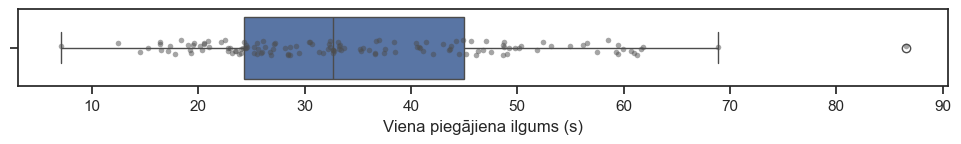

In [314]:
# exercise duration can be calculated from events_df start_watch and end_watch columns
events_df["duration"] = events_df["end_watch"] - events_df["start_watch"]
exercise_durations = events_df[["group", "duration"]].groupby("group").sum() / 1000 / 60
display(exercise_durations.style.format("{:.2f} minutes"))
total_exercise_duration = events_df["duration"].sum()
total_exercise_duration_min = total_exercise_duration / 1000 / 60
print(f"Total exercise duration (minutes): {total_exercise_duration_min:.2f}")

# average exercise duration of one set by group
average_exercise_duration = events_df[["group", "duration"]].groupby("group").mean() / 1000
display(average_exercise_duration.style.format("{:.2f} seconds"))
# overall average set duration
overall_average_duration = events_df["duration"].mean() / 1000
print(f"Overall average set duration: {overall_average_duration:.2f} seconds")

# plot boxplot of all exercise durations in seconds
def plot_exercise_durations(events_df):
    plt.figure(figsize=(12,1))
    sns.boxplot(x=events_df["duration"] / 1000)
    sns.stripplot(x=events_df["duration"] / 1000, size=4, color=".3", alpha=0.5)
    plt.xlabel("Viena piegājiena ilgums (s)")
    plt.show()

plot_exercise_durations(events_df)

In [315]:
# exercise/rest proportions
# format total duration hours so that it prints hours and minutes
def print_time(hours):
    h = int(hours)
    m = int((hours - h) * 60)
    return f"{h} hours and {m} minutes"
print(f"Total duration: {print_time(total_duration_hours)}")
print(f"Exercise duration: {total_exercise_duration_min:.2f} minutes")
# proportion of exercise duration to total duration
exercise_proportion = total_exercise_duration / total_duration
print(f"Exercise proportion: {exercise_proportion:.2%}")

# shortest and longest session
session_durations = [info["watch_end_timestamp"] - info["watch_start_timestamp"] for info in all_info]
shortest_session = min(session_durations) / 1000 / 60
longest_session = max(session_durations) / 1000 / 60
print(f"Shortest session: {print_time(shortest_session / 60)}")
print(f"Longest session: {print_time(longest_session / 60)}")
# average session duration
average_session_duration = np.mean(session_durations) / 1000 / 60
print(f"Average session duration: {print_time(average_session_duration / 60)}")

Total duration: 9 hours and 46 minutes
Exercise duration: 81.99 minutes
Exercise proportion: 13.99%
Shortest session: 0 hours and 37 minutes
Longest session: 2 hours and 9 minutes
Average session duration: 1 hours and 23 minutes


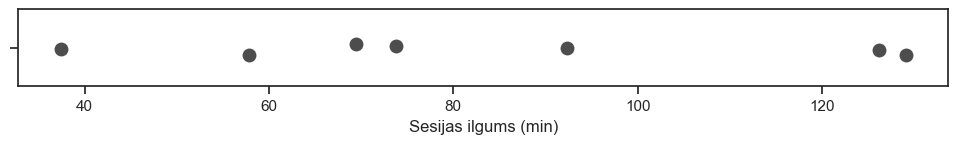

In [316]:
# boxplot of session durations in minutes
def plot_session_durations(all_info):
    session_durations = [(info["watch_end_timestamp"] - info["watch_start_timestamp"]) / 1000 / 60 for info in all_info]
    plt.figure(figsize=(12,1))
    sns.stripplot(x=session_durations, size=10, color=".3")
    plt.xlabel("Sesijas ilgums (min)")
    plt.show()
plot_session_durations(all_info)

In [317]:
# table of exercise group, name, count, total duration in minutes
exercise_summary = events_df.groupby(["group", "name"]).agg(
    count=("name", "count"),
    total_duration=("duration", "sum")
).reset_index()

exercise_summary["total_duration"] = exercise_summary["total_duration"] / 1000 / 60
exercise_summary = exercise_summary.sort_values(by=["group", "name"], key=lambda x: x.map(lambda v: GROUP_ORDER.index(v) if v in GROUP_ORDER else 999))
exercise_summary.style.format(decimal=",", precision=2)

,group,name,count,total_duration
32,Vēders,Ab Crunch Machine,7,"3,77"
33,Vēders,Ab Roll Outs,1,"0,12"
34,Vēders,Crunches,4,"3,47"
35,Vēders,Leg Raises,4,"1,57"
36,Vēders,Plank,2,"1,58"
0,Bicepsi,Dumbbell Bicep Curls,5,"2,26"
1,Bicepsi,Hammer Curls,2,"1,24"
2,Bicepsi,Incline Dumbbell Curls,4,"3,36"
3,Bicepsi,Preacher Curls,5,"3,44"
29,Tricepsi,Cable Overhead Extensions,3,"1,87"


In [523]:
def classification_report_per_session(
    df,
    truth_col="ground_truth",
    prediction_col="prediction_binary",
    session_col="session_id",
):
    rows = []

    for session_id, session_df in df.groupby(session_col):
        y_true = session_df[truth_col].astype(int)
        y_pred = session_df[prediction_col].astype(int)

        report = classification_report(
            y_true,
            y_pred,
            output_dict=True,
            zero_division=0
        )

        row = {
            "session_id": session_id,

            "accuracy": report["accuracy"],

            "precision_macro": report["macro avg"]["precision"],
            "precision_weighted": report["weighted avg"]["precision"],
            "precision_0": report["0"]["precision"],
            "precision_1": report["1"]["precision"],

            "recall_macro": report["macro avg"]["recall"],
            "recall_weighted": report["weighted avg"]["recall"],
            "recall_0": report["0"]["recall"],
            "recall_1": report["1"]["recall"],

            "f1_macro": report["macro avg"]["f1-score"],
            "f1_weighted": report["weighted avg"]["f1-score"],
            "f1_0": report["0"]["f1-score"],
            "f1_1": report["1"]["f1-score"],

            "support_0": report["0"]["support"],
            "support_1": report["1"]["support"],
        }

        rows.append(row)

    return pd.DataFrame(rows).sort_values("session_id").reset_index(drop=True)

In [530]:
print("Classification report:")
print(classification_report(
    windows_df["ground_truth"],
    windows_df["prediction_binary"],
    zero_division=0
))

print("Classification report (fine-tuned):")
print(classification_report(
    windows_df["ground_truth"],
    windows_df["prediction_finetuned_binary"],
    zero_division=0
))

Classification report:
              precision    recall  f1-score   support

           0       0.93      0.92      0.93     29215
           1       0.56      0.61      0.58      4887

    accuracy                           0.87     34102
   macro avg       0.74      0.76      0.75     34102
weighted avg       0.88      0.87      0.88     34102

Classification report (fine-tuned):
              precision    recall  f1-score   support

           0       0.97      0.93      0.95     29215
           1       0.66      0.82      0.73      4887

    accuracy                           0.91     34102
   macro avg       0.82      0.88      0.84     34102
weighted avg       0.93      0.91      0.92     34102



In [620]:
def classification_report_summary_table(df, truth_col="ground_truth", prediction_col="prediction_binary"):
    report = classification_report(df[truth_col], df[prediction_col], output_dict=True, zero_division=0)

    summary = {
        "accuracy": report["accuracy"],

        "precision_macro": report["macro avg"]["precision"],
        "precision_weighted": report["weighted avg"]["precision"],
        "precision_0": report["0"]["precision"],
        "precision_1": report["1"]["precision"],

        "recall_macro": report["macro avg"]["recall"],
        "recall_weighted": report["weighted avg"]["recall"],
        "recall_0": report["0"]["recall"],
        "recall_1": report["1"]["recall"],

        "f1_macro": report["macro avg"]["f1-score"],
        "f1_weighted": report["weighted avg"]["f1-score"],
        "f1_0": report["0"]["f1-score"],
        "f1_1": report["1"]["f1-score"],

        "support_0": report["0"]["support"],
        "support_1": report["1"]["support"],
    }

    return pd.Series(summary)

# Classification report summary table

In [627]:
summary_original = classification_report_summary_table(windows_df)
summary_finetuned = classification_report_summary_table(
    windows_df,
    prediction_col="prediction_finetuned_binary"
)

selected_metrics = ["precision_1", "recall_1", "f1_1", "f1_0", "f1_macro"]

summary_original = summary_original[selected_metrics]
summary_finetuned = summary_finetuned[selected_metrics]

# Combine summaries as rows
summary_df = pd.DataFrame([summary_original, summary_finetuned], index=['Original', 'Finetuned'])

summary_df.style.format(decimal=",", precision=2).background_gradient(
    subset=selected_metrics,
    cmap="RdYlGn",
    vmin=0.5,
    vmax=1
)

,precision_1,recall_1,f1_1,f1_0,f1_macro
Original,"0,56","0,61","0,58","0,93","0,75"
Finetuned,"0,66","0,82","0,73","0,95","0,84"


## Per session

In [ ]:
print("Classification report per session:")
session_report = classification_report_per_session(
    df=windows_df,
    truth_col="ground_truth",
    prediction_col="prediction_binary",
    session_col="session_id"
)

selected_metrics = ["precision_1", "recall_1", "f1_1", "f1_0", "f1_macro"]

session_report = session_report[["session_id"] + selected_metrics]

display(session_report.style.format(decimal=",", precision=2).background_gradient(
    subset=selected_metrics,
    cmap="RdYlGn",
    vmin=0.5,
    vmax=1
))

print("Classification report per session (fine-tuned):")
session_report = classification_report_per_session(
    df=windows_df,
    truth_col="ground_truth",
    prediction_col="prediction_finetuned_binary",
    session_col="session_id"
)

session_report = session_report[["session_id"] + selected_metrics]

display(session_report.style.format(decimal=",", precision=2).background_gradient(
    subset=selected_metrics,
    cmap="RdYlGn",
    vmin=0.5,
    vmax=1
))


Classification report per session:


,session_id,precision_1,recall_1,f1_1,f1_0,f1_macro
0,1,"0,64","0,76","0,69","0,93","0,81"
1,2,"0,48","0,81","0,60","0,93","0,77"
2,3,"0,68","0,55","0,61","0,91","0,76"
3,4,"0,49","0,43","0,46","0,89","0,67"
4,5,"0,75","0,44","0,56","0,92","0,74"
5,6,"0,61","0,62","0,61","0,93","0,77"
6,7,"0,41","0,65","0,50","0,95","0,72"


Classification report per session (fine-tuned):


,session_id,precision_1,recall_1,f1_1,f1_0,f1_macro
0,1,"0,78","0,78","0,78","0,96","0,87"
1,2,"0,60","0,95","0,74","0,95","0,85"
2,3,"0,83","0,91","0,87","0,96","0,91"
3,4,"0,56","0,85","0,68","0,91","0,79"
4,5,"0,83","0,71","0,76","0,95","0,86"
5,6,"0,73","0,76","0,75","0,95","0,85"
6,7,"0,48","0,79","0,59","0,95","0,77"


# Group coverage

## Methods

In [674]:
def calculate_group_coverage(
    df,
    truth_col="ground_truth",
    prediction_col="prediction_binary",
    group_col="ground_truth_group"
):
    exercise_windows = df[df[truth_col] == 1].copy()

    coverage = (
        exercise_windows
        .groupby(group_col)
        .agg(
            total_exercise_windows=(truth_col, "count"),
            predicted_exercise_windows=(prediction_col, "sum")
        )
        .reset_index()
    )

    coverage["coverage"] = (
        coverage["predicted_exercise_windows"] /
        coverage["total_exercise_windows"]
    )

    coverage["coverage_percent"] = coverage["coverage"] * 100

    return coverage.sort_values("coverage_percent", ascending=False)

In [687]:
def plot_group_coverage(
    group_coverage_df,
    group_col="ground_truth_group",
    coverage_col="coverage_percent",
    title="Muskuļu grupu kopējais pārklājums",
    xlabel="Pārklājums (%)",
    ylabel="Muskuļu grupa",
    xlim=(0, 100)
):
    plot_df = group_coverage_df.sort_values(coverage_col, ascending=False).copy()

    f, ax = plt.subplots(figsize=(8, 4))

    sns.barplot(
        data=plot_df,
        x=coverage_col,
        y=group_col,
        color="skyblue",
        ax=ax
    )

    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f", padding=3)

    ax.set_xlim(*xlim)
    ax.set(
        xlabel=xlabel,
        ylabel=ylabel,
        title=title
    )

    ax.xaxis.grid(True)
    sns.despine(trim=True, left=True)
    plt.tight_layout()
    plt.show()

In [690]:
def compare_group_coverage(
    df,
    truth_col="ground_truth",
    base_prediction_col="prediction_binary",
    finetuned_prediction_col="prediction_finetuned_binary",
    group_col="ground_truth_group"
):
    base = calculate_group_coverage(
        df=df,
        truth_col=truth_col,
        prediction_col=base_prediction_col,
        group_col=group_col
    )
    base["Modelis"] = "Sākotnējais"

    finetuned = calculate_group_coverage(
        df=df,
        truth_col=truth_col,
        prediction_col=finetuned_prediction_col,
        group_col=group_col
    )
    finetuned["Modelis"] = "Pielāgotais"

    return pd.concat([base, finetuned], ignore_index=True)

In [691]:
def plot_group_coverage_comparison(
    group_coverage_comparison,
    group_col="ground_truth_group",
    coverage_col="coverage_percent",
    model_col="Modelis",
    title="Muskuļu grupu pārklājuma salīdzinājums",
    xlabel="Pārklājums (%)",
    ylabel="Muskuļu grupa",
    xlim=(0, 100),
    group_order=None
):
    plot_df = group_coverage_comparison.copy()

    model_order = ["Sākotnējais", "Pielāgotais"]

    if group_order is not None:
        plot_df[group_col] = pd.Categorical(
            plot_df[group_col],
            categories=group_order,
            ordered=True
        )
    else:
        order_df = (
            plot_df[plot_df[model_col] == "Pielāgotais"]
            .sort_values(coverage_col, ascending=False)
        )
        group_order = order_df[group_col].tolist()

        plot_df[group_col] = pd.Categorical(
            plot_df[group_col],
            categories=group_order,
            ordered=True
        )

    plot_df = plot_df.sort_values(group_col)

    f, ax = plt.subplots(figsize=(9, 4.5))

    sns.barplot(
        data=plot_df,
        x=coverage_col,
        y=group_col,
        hue=model_col,
        hue_order=model_order,
        palette="vlag",
        ax=ax
    )

    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f", padding=3)

    ax.set_xlim(*xlim)
    ax.set(
        xlabel=xlabel,
        ylabel=ylabel,
        title=title
    )

    ax.xaxis.grid(True)
    ax.legend(title="Modelis")

    sns.despine(trim=True, left=True)
    plt.tight_layout()
    plt.show()

In [698]:
def calculate_group_session_coverage(
    df,
    truth_col="ground_truth",
    prediction_col="prediction_binary",
    session_col="session_id",
    group_col="ground_truth_group"
):
    exercise_df = df[df[truth_col] == 1].copy()

    coverage_df = (
        exercise_df
        .groupby([group_col, session_col])
        .agg(
            total_exercise_windows=(truth_col, "count"),
            predicted_exercise_windows=(prediction_col, "sum")
        )
        .reset_index()
    )

    coverage_df["coverage"] = (
        coverage_df["predicted_exercise_windows"] /
        coverage_df["total_exercise_windows"]
    )

    coverage_df["coverage_percent"] = coverage_df["coverage"] * 100

    return coverage_df

In [705]:
def make_group_session_coverage_pivot(
    coverage_df,
    group_col="ground_truth_group",
    session_col="session_id",
    value_col="coverage_percent",
    group_order=None,
    session_order=None
):
    pivot_df = coverage_df.pivot(
        index=group_col,
        columns=session_col,
        values=value_col
    )

    if group_order is not None:
        pivot_df = pivot_df.reindex(group_order)

    if session_order is not None:
        pivot_df = pivot_df[session_order]

    return pivot_df

In [722]:
def plot_group_session_coverage_heatmap(
    coverage_pivot,
    title="Muskuļu grupu pārklājums pa sesijām",
    xlabel="Sesija",
    ylabel=None,
    cmap="RdYlGn",
    vmin=0,
    vmax=100,
    center=None,
    annot=True,
    fmt=".1f"
):
    plt.figure(figsize=(9, 5))

    ax = sns.heatmap(
        coverage_pivot,
        annot=annot,
        fmt=fmt,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        center=center,
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "Pārklājums (%)"}
    )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    plt.tight_layout()
    plt.show()

In [723]:
def plot_group_session_coverage_heatmaps_side_by_side(
    coverage_pivot_left,
    coverage_pivot_right,
    title_left="Sākotnējais modelis",
    title_right="Pielāgotais modelis",
    main_title="Muskuļu grupu pārklājums pa sesijām",
    xlabel="Sesija",
    ylabel="Muskuļu grupa",
    cmap="RdYlGn",
    vmin=0,
    vmax=100,
    center=None,
    annot=True,
    fmt=".1f",
    figsize=(14, 5)
):
    fig, axes = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=figsize,
        sharey=True,
        constrained_layout=True
    )

    # One shared colorbar axis
    cbar_ax = fig.add_axes([1.01, 0.18, 0.015, 0.65])

    sns.heatmap(
        coverage_pivot_left,
        annot=annot,
        fmt=fmt,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        center=center,
        linewidths=0.5,
        linecolor="white",
        cbar=False,
        ax=axes[0]
    )

    sns.heatmap(
        coverage_pivot_right,
        annot=annot,
        fmt=fmt,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        center=center,
        linewidths=0.5,
        linecolor="white",
        cbar=True,
        cbar_ax=cbar_ax,
        cbar_kws={"label": "Pārklājums (%)"},
        ax=axes[1]
    )

    axes[0].set_title(title_left)
    axes[1].set_title(title_right)

    axes[0].set_xlabel(xlabel)
    axes[1].set_xlabel(xlabel)

    axes[0].set_ylabel(ylabel)
    axes[1].set_ylabel(None)

    fig.suptitle(main_title, fontsize=14)

    plt.show()

## stats

In [677]:
group_coverage = calculate_group_coverage(
    df=windows_df,
    truth_col="ground_truth",
    prediction_col="prediction_binary",
    group_col="ground_truth_group"
)

display(group_coverage.style.format(decimal=",", precision=2))

group_coverage_finetuned = calculate_group_coverage(
    df=windows_df,
    truth_col="ground_truth",
    prediction_col="prediction_finetuned_binary",
    group_col="ground_truth_group"
)

display(group_coverage_finetuned.style.format(decimal=",", precision=2))

,ground_truth_group,total_exercise_windows,predicted_exercise_windows,coverage,coverage_percent
2,Kājas,1144,1002,"0,88","87,59"
0,Bicepsi,614,513,"0,84","83,55"
5,Tricepsi,503,376,"0,75","74,75"
6,Vēders,627,367,"0,59","58,53"
3,Mugura,748,312,"0,42","41,71"
1,Krūtis,742,276,"0,37","37,20"
4,Pleci,509,134,"0,26","26,33"


,ground_truth_group,total_exercise_windows,predicted_exercise_windows,coverage,coverage_percent
0,Bicepsi,614,562,"0,92","91,53"
5,Tricepsi,503,445,"0,88","88,47"
2,Kājas,1144,1011,"0,88","88,37"
3,Mugura,748,655,"0,88","87,57"
1,Krūtis,742,570,"0,77","76,82"
4,Pleci,509,370,"0,73","72,69"
6,Vēders,627,413,"0,66","65,87"


In [693]:
group_coverage_comparison = compare_group_coverage(
    windows_df,
    truth_col="ground_truth",
    base_prediction_col="prediction_binary",
    finetuned_prediction_col="prediction_finetuned_binary",
    group_col="ground_truth_group"
)

display(group_coverage_comparison.style.format(decimal=",", precision=2))

,ground_truth_group,total_exercise_windows,predicted_exercise_windows,coverage,coverage_percent,Modelis
0,Kājas,1144,1002,"0,88","87,59",Sākotnējais
1,Bicepsi,614,513,"0,84","83,55",Sākotnējais
2,Tricepsi,503,376,"0,75","74,75",Sākotnējais
3,Vēders,627,367,"0,59","58,53",Sākotnējais
4,Mugura,748,312,"0,42","41,71",Sākotnējais
5,Krūtis,742,276,"0,37","37,20",Sākotnējais
6,Pleci,509,134,"0,26","26,33",Sākotnējais
7,Bicepsi,614,562,"0,92","91,53",Pielāgotais
8,Tricepsi,503,445,"0,88","88,47",Pielāgotais
9,Kājas,1144,1011,"0,88","88,37",Pielāgotais


## plots

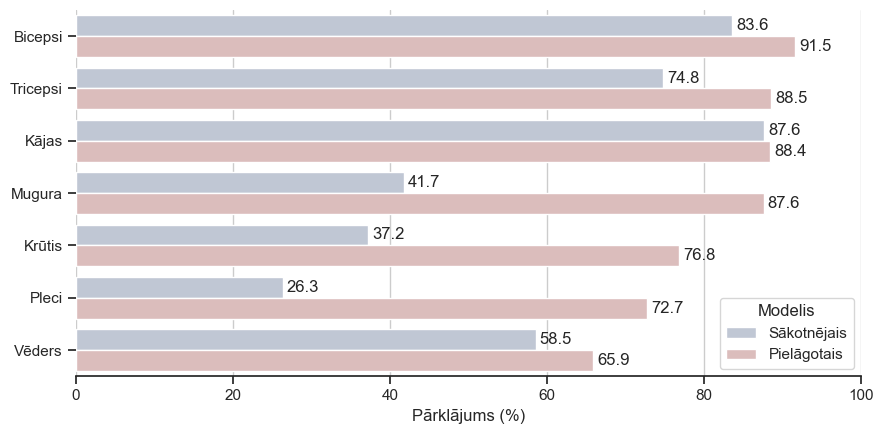

In [726]:
plot_group_coverage_comparison(
    group_coverage_comparison,
    title="",
    ylabel="",
    
)

In [702]:
group_session_coverage = calculate_group_session_coverage(
    windows_df,
    truth_col="ground_truth",
    prediction_col="prediction_binary",
    session_col="session_id",
    group_col="ground_truth_group"
)

display(group_session_coverage.head(10).style.format(decimal=",", precision=2))

group_session_coverage_finetuned = calculate_group_session_coverage(
    windows_df,
    truth_col="ground_truth",
    prediction_col="prediction_finetuned_binary",
    session_col="session_id",
    group_col="ground_truth_group"
)

,ground_truth_group,session_id,total_exercise_windows,predicted_exercise_windows,coverage,coverage_percent
0,Bicepsi,1,73,57,"0,78","78,08"
1,Bicepsi,2,75,63,"0,84","84,00"
2,Bicepsi,3,104,86,"0,83","82,69"
3,Bicepsi,4,61,58,"0,95","95,08"
4,Bicepsi,5,48,39,"0,81","81,25"
5,Bicepsi,6,156,144,"0,92","92,31"
6,Bicepsi,7,97,66,"0,68","68,04"
7,Krūtis,1,88,69,"0,78","78,41"
8,Krūtis,2,91,74,"0,81","81,32"
9,Krūtis,3,104,2,"0,02","1,92"


In [717]:
coverage_pivot = make_group_session_coverage_pivot(
    group_session_coverage,
    group_order=GROUP_ORDER
)

coverage_pivot_finetuned = make_group_session_coverage_pivot(
    group_session_coverage_finetuned,
    group_order=GROUP_ORDER
)

display(coverage_pivot.style.format(decimal=",", precision=1))

session_id,1,2,3,4,5,6,7
ground_truth_group,,,,,,,
Vēders,"70,7","67,3","95,9","32,5","45,9","52,6","54,7"
Bicepsi,"78,1","84,0","82,7","95,1","81,2","92,3","68,0"
Tricepsi,"94,8","84,6","91,9","83,8","25,0","72,3","17,5"
Mugura,"3,9","85,6","2,7","23,5","59,8","50,7","49,3"
Krūtis,"78,4","81,3","1,9","11,9","10,7","32,9","80,0"
Kājas,"96,8","94,4","87,0","64,1","70,0","91,7","98,8"
Pleci,"92,1","38,1","2,0","5,1","5,9","39,8","0,0"


## Heatmap

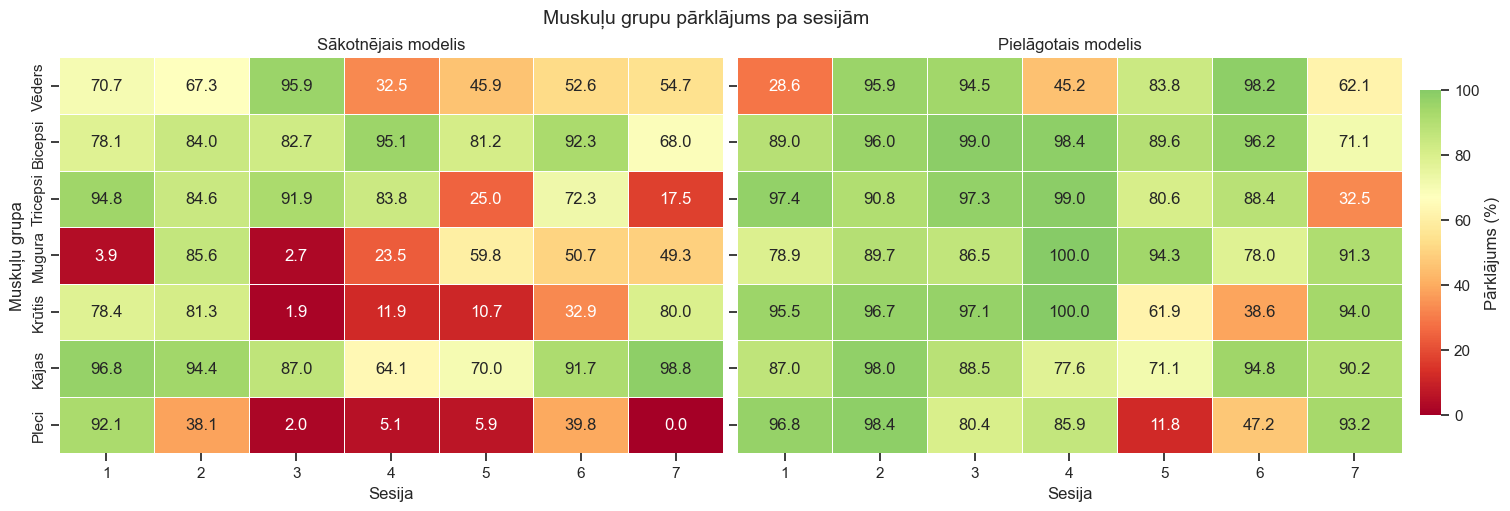

In [725]:
plot_group_session_coverage_heatmaps_side_by_side(
    coverage_pivot,
    coverage_pivot_finetuned,
    title_left="Sākotnējais modelis",
    title_right="Pielāgotais modelis",
    main_title="Muskuļu grupu pārklājums pa sesijām",
    figsize=(14, 5),
    center=67
)

# Stability/ segment analysis

## Fragmentation methods

### Plot Methods

In [744]:
def plot_fragmentation_distribution(fragmentation_df):
    f, ax = plt.subplots(figsize=(7, 4))

    sns.countplot(
        data=fragmentation_df,
        x="fragment_count",
        color="skyblue"
    )

    ax.set(
        xlabel="Fragmentu skaits",
        ylabel="Segmentu skaits",
        #title="Vingrošanas segmentu fragmentācija"
    )

    ax.xaxis.grid(True)

    sns.despine()

    plt.show()


def plot_fragmentation_distribution_comparison(
    fragmentation_df,
    fragmentation_df_finetuned
):
    df_before = fragmentation_df.copy()
    df_before["Modelis"] = "Sākotnējais"

    df_after = fragmentation_df_finetuned.copy()
    df_after["Modelis"] = "Pielāgotais"

    combined_df = pd.concat([df_before, df_after], ignore_index=True)

    model_order = ["Sākotnējais", "Pielāgotais"]

    f, ax = plt.subplots(figsize=(9, 4))

    sns.histplot(
        data=combined_df,
        x="fragment_count",
        hue="Modelis",
        hue_order=model_order,
        discrete=True,
        stat="percent",
        multiple="dodge",
        shrink=0.8,
        common_norm=False,
        ax=ax
    )

    ax.set(
        xlabel="Fragmentu skaits",
        ylabel="Segmentu īpatsvars (%)"
    )

    max_fragments = int(combined_df["fragment_count"].max())
    ax.set_xticks(range(0, max_fragments + 1))

    ax.xaxis.grid(True)

    sns.despine()
    plt.tight_layout()
    plt.show()

def plot_fragmentation_per_exercise(fragmentation_df):
    df = fragmentation_df.copy()

    # ordered categorical group
    df["group"] = pd.Categorical(
        df["group"],
        categories=GROUP_ORDER,
        ordered=True
    )

    # exercise order grouped by muscle group
    exercise_order = (
        df[["group", "name"]]
        .drop_duplicates()
        .sort_values(["group", "name"])
    )["name"].tolist()

    f, ax = plt.subplots(
        figsize=(9, max(3, len(exercise_order) * 0.35))
    )

    sns.boxplot(
        data=df,
        x="fragment_count",
        y="name",
        order=exercise_order,
        color="skyblue",
        whis=[0, 100],
        ax=ax
    )

    sns.stripplot(
        data=df,
        x="fragment_count",
        y="name",
        order=exercise_order,
        size=4,
        color=".3",
        alpha=0.5,
        ax=ax
    )

    ax.set(
        xlabel="Fragmentu skaits",
        ylabel="Vingrinājums"
    )

    max_fragments = df["fragment_count"].max()

    ax.set_xticks(range(0, max_fragments + 1))

    ax.xaxis.grid(True)

    # ---- Add group labels and separators ----

    group_positions = []

    current_y = 0

    for group in GROUP_ORDER:
        exercises = [
            ex for ex in exercise_order
            if EXERCISE_GROUPS.get(ex) == group
        ]

        if not exercises:
            continue

        start_y = current_y
        end_y = current_y + len(exercises) - 1
        middle_y = (start_y + end_y) / 2

        group_positions.append((group, middle_y))

        # separator line
        if start_y != 0:
            ax.axhline(
                start_y - 0.5,
                color="lightgray",
                linewidth=1
            )

        current_y += len(exercises)

    # right-side group labels
    xmax = ax.get_xlim()[1]

    for group, y in group_positions:
        ax.text(
            xmax + 0.2,
            y,
            group,
            va="center",
            fontsize=10,
            fontweight="bold"
        )

    sns.despine(trim=True, left=True)

    plt.tight_layout()
    plt.show()

def plot_fragmentation_per_session(fragmentation_df):
    f, ax = plt.subplots(figsize=(8, 4))

    sns.boxplot(
        data=fragmentation_df,
        x="fragment_count",
        y=fragmentation_df["session_id"].astype(str),
        whis=[0, 100],
        color="skyblue"
    )

    sns.stripplot(
        data=fragmentation_df,
        x="fragment_count",
        y=fragmentation_df["session_id"].astype(str),
        color=".3",
        alpha=0.5,
        size=4
    )

    ax.set(
        xlabel="Fragmentu skaits",
        ylabel="Sesija",
        #title="Vingrošanas segmentu fragmentācija pa sesijām"
    )

    max_fragments = fragmentation_df["fragment_count"].max()

    ax.set_xticks(range(0, max_fragments + 1))

    ax.xaxis.grid(True)

    sns.despine(trim=True)

    plt.show()

def plot_fragmentation_per_session_comparison(fragmentation_df, fragmentation_df_finetuned):
    df_before = fragmentation_df.copy()
    df_before["model"] = "Pirms pielāgošanas"

    df_after = fragmentation_df_finetuned.copy()
    df_after["model"] = "Pēc pielāgošanas"

    combined_df = pd.concat([df_before, df_after], ignore_index=True)
    combined_df["session_id"] = combined_df["session_id"].astype(str)

    f, ax = plt.subplots(figsize=(9, 4))

    sns.boxplot(
        data=combined_df,
        x="fragment_count",
        y="session_id",
        hue="model",
        whis=[0, 100],
        dodge=True
    )

    sns.stripplot(
        data=combined_df,
        x="fragment_count",
        y="session_id",
        hue="model",
        dodge=True,
        palette="dark:.3",
        alpha=0.45,
        size=4
    )

    ax.set(
        xlabel="Fragmentu skaits",
        ylabel="Sesija"
    )

    max_fragments = combined_df["fragment_count"].max()
    ax.set_xticks(range(0, max_fragments + 1))

    ax.xaxis.grid(True)

    # Remove duplicate legends caused by boxplot + stripplot
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles[:2],
        labels[:2],
        title="Modelis",
        loc="best"
    )

    sns.despine(trim=True)
    plt.tight_layout()
    plt.show()

def plot_fragmentation_per_group(fragmentation_df):
    f, ax = plt.subplots(figsize=(8, 4))

    sns.boxplot(
        data=fragmentation_df,
        x="fragment_count",
        y="group",
        whis=[0, 100],
        color="skyblue"
    )

    sns.stripplot(
        data=fragmentation_df,
        x="fragment_count",
        y="group",
        color=".3",
        alpha=0.5,
        size=4
    )

    ax.set(
        xlabel="Fragmentu skaits",
        ylabel="Muskuļu grupa",
    )

    max_fragments = fragmentation_df["fragment_count"].max()

    ax.set_xticks(range(0, max_fragments + 1))

    ax.xaxis.grid(True)

    sns.despine(trim=True)

    plt.show()

def plot_fragmentation_per_group_comparison(fragmentation_df, fragmentation_df_finetuned):
    df_before = fragmentation_df.copy()
    df_before["model"] = "Pirms pielāgošanas"

    df_after = fragmentation_df_finetuned.copy()
    df_after["model"] = "Pēc pielāgošanas"

    combined_df = pd.concat([df_before, df_after], ignore_index=True)

    f, ax = plt.subplots(figsize=(9, 4))

    sns.boxplot(
        data=combined_df,
        x="fragment_count",
        y="group",
        hue="model",
        whis=[0, 100],
        dodge=True,
        ax=ax
    )

    sns.stripplot(
        data=combined_df,
        x="fragment_count",
        y="group",
        hue="model",
        dodge=True,
        palette="dark:.3",
        alpha=0.45,
        size=4,
        ax=ax
    )

    ax.set(
        xlabel="Fragmentu skaits",
        ylabel="Muskuļu grupa"
    )

    max_fragments = int(combined_df["fragment_count"].max())
    ax.set_xticks(range(0, max_fragments + 1))

    ax.xaxis.grid(True)

    # Remove duplicate legends from boxplot + stripplot
    handles, labels = ax.get_legend_handles_labels()

    ax.legend(
        handles[:2],
        labels[:2],
        title="Modelis",
        loc="best"
    )

    sns.despine(trim=True)
    plt.tight_layout()
    plt.show()

### Get segments methods

In [419]:
from dataclasses import dataclass

@dataclass
class ExerciseSegment:
    name: str
    session: str
    session_id: int
    start_watch: int
    end_watch: int
    data: pd.DataFrame

def get_exercise_segments(
    windows_df: pd.DataFrame,
    events_df: pd.DataFrame
) -> list[ExerciseSegment]:

    segments = []

    for _, event in events_df.iterrows():

        segment_df = windows_df[
            (windows_df["session"] == event["session"]) &
            (windows_df["timestamp"] >= event["start_watch"]) &
            (windows_df["timestamp"] <= event["end_watch"])
        ].copy()

        segments.append({
            "name": event["name"],
            "group": event["group"],
            "session": event["session"],
            "session_id": event["session_id"],
            "start_watch": event["start_watch"],
            "end_watch": event["end_watch"],
            "data": segment_df
        })

    return segments

def get_rest_segments(windows_df: pd.DataFrame) -> list[pd.DataFrame]:
    rest_df = windows_df[
        windows_df["ground_truth"] == 0
    ].copy()

    segments = []

    current_segment = []

    for _, row in rest_df.iterrows():
        if not current_segment:
            current_segment.append(row)
            continue

        prev_ts = current_segment[-1]["timestamp"]

        # gap threshold
        if row["timestamp"] - prev_ts > 3000:
            segments.append(pd.DataFrame(current_segment))
            current_segment = []

        current_segment.append(row)

    if current_segment:
        segments.append(pd.DataFrame(current_segment))

    return segments

### Fragmentation calculation methods

In [320]:
def calculate_fragmentation(segments, prediction_col="prediction_binary"):
    results = []

    for segment in segments:
        df = segment["data"]

        preds = df[prediction_col].fillna(0).astype(int)

        fragment_starts = (
            (preds == 1) &
            (preds.shift(fill_value=0) == 0)
        )

        fragment_count = fragment_starts.sum()

        results.append({
            "name": segment["name"],
            "group": segment["group"],
            "session": segment["session"],
            "session_id": segment["session_id"],
            "detected": fragment_count > 0,
            "fragment_count": fragment_count,
            "extra_fragments": max(fragment_count - 1, 0)  
        })

    return pd.DataFrame(results)

In [321]:
def calculate_fragmentation_statistics(fragmentation_df):
    fc = fragmentation_df["fragment_count"]

    stats = {
        "Vidējais": fc.mean(),
        "Mediānais": fc.median(),
        "Q1": fc.quantile(0.25),
        "Q3": fc.quantile(0.75),
        "Standartnovirze": fc.std(),
        "Maksimālais": fc.max(),
        "Segmenti ar 1 fragmentu (%)": (fc == 1).mean() * 100,
        "Segmenti ar >=2 fragmentiem (%)": (fc >= 2).mean() * 100,
        "Segmenti ar >=3 fragmentiem (%)": (fc >= 3).mean() * 100,
        "Segmenti ar >=4 fragmentiem (%)": (fc >= 4).mean() * 100,
        "Segmenti ar >=5 fragmentiem (%)": (fc >= 5).mean() * 100,
        "Segmentu skaits": len(fragmentation_df),
        "Nenoteikto segmentu skaits": (fc == 0).sum(),
        "Nenoteikti segmenti (%)": (fc == 0).mean() * 100
    }

    summary = pd.DataFrame([stats])

    # transpose and rename columns
    summary = summary.transpose()

    return summary

In [322]:
def calculate_fragmentation_per_session(fragmentation_df):
    grouped = fragmentation_df.groupby("session")

    stats_df = grouped["fragment_count"].agg([
        ("Vidējais", "mean"),
        ("Mediānais", "median"),
        ("Q1", lambda x: x.quantile(0.25)),
        ("Q3", lambda x: x.quantile(0.75)),
        ("Maksimālais", "max"),
        ("Standartnovirze", "std"),
        ("Segmenti ar 1 fragmentu (%)", lambda x: (x == 1).mean() * 100),
        ("Segmenti ar >=2 fragmentiem (%)", lambda x: (x >= 2).mean() * 100),
        ("Segmenti ar >=3 fragmentiem (%)", lambda x: (x >= 3).mean() * 100),
        ("Segmenti ar >=4 fragmentiem (%)", lambda x: (x >= 4).mean() * 100),
        ("Segmenti ar >=5 fragmentiem (%)", lambda x: (x >= 5).mean() * 100),
        ("Segmentu skaits", "count"),
        ("Nenoteikto segmentu skaits", lambda x: (x == 0).sum()),
        ("Nenoteikti segmenti (%)", lambda x: (x == 0).mean() * 100)
    ]).reset_index()

    return stats_df

def calculate_fragmentation_per_group(fragmentation_df):
    grouped = fragmentation_df.groupby("group")

    stats_df = grouped["fragment_count"].agg([
        ("Vidējais", "mean"),
        ("Mediānais", "median"),
        ("Q1", lambda x: x.quantile(0.25)),
        ("Q3", lambda x: x.quantile(0.75)),
        ("Maksimālais", "max"),
        ("Standartnovirze", "std"),
        ("Segmenti ar 1 fragmentu (%)", lambda x: (x == 1).mean() * 100),
        ("Segmenti ar >=2 fragmentiem (%)", lambda x: (x >= 2).mean() * 100),
        ("Segmenti ar >=3 fragmentiem (%)", lambda x: (x >= 3).mean() * 100),
        ("Segmenti ar >=4 fragmentiem (%)", lambda x: (x >= 4).mean() * 100),
        ("Segmenti ar >=5 fragmentiem (%)", lambda x: (x >= 5).mean() * 100),
        ("Segmentu skaits", "count"),
        ("Nenoteikto segmentu skaits", lambda x: (x == 0).sum()),
        ("Nenoteikti segmenti (%)", lambda x: (x == 0).mean() * 100)
    ]).reset_index()

    return stats_df

In [386]:
# Get exercise segments
exercise_segments = get_exercise_segments(windows_df, events_df)

In [387]:
# Calculate fragmentation for each segment
fragmentation_df = calculate_fragmentation(exercise_segments)
display(fragmentation_df)

# Calculated for finetuned predictions
fragmentation_df_finetuned = calculate_fragmentation(exercise_segments, prediction_col="prediction_finetuned_binary")
display(fragmentation_df_finetuned)

,name,group,session,session_id,detected,fragment_count,extra_fragments
0,Goblet Squats,Kājas,session_1776786984700,1,True,1,0
1,Goblet Squats,Kājas,session_1776786984700,1,True,1,0
2,Dumbbell Bicep Curls,Bicepsi,session_1776786984700,1,True,8,7
3,Dumbbell Bicep Curls,Bicepsi,session_1776786984700,1,True,8,7
4,Dumbbell Bicep Curls,Bicepsi,session_1776786984700,1,True,1,0
...,...,...,...,...,...,...,...
135,Dumbbell Overhead Press,Pleci,session_1777462103399,7,False,0,0
136,Dumbbell Overhead Press,Pleci,session_1777462103399,7,False,0,0
137,Leg Raises,Vēders,session_1777462103399,7,True,7,6
138,Leg Raises,Vēders,session_1777462103399,7,True,3,2


,name,group,session,session_id,detected,fragment_count,extra_fragments
0,Goblet Squats,Kājas,session_1776786984700,1,True,1,0
1,Goblet Squats,Kājas,session_1776786984700,1,True,1,0
2,Dumbbell Bicep Curls,Bicepsi,session_1776786984700,1,True,6,5
3,Dumbbell Bicep Curls,Bicepsi,session_1776786984700,1,True,1,0
4,Dumbbell Bicep Curls,Bicepsi,session_1776786984700,1,True,1,0
...,...,...,...,...,...,...,...
135,Dumbbell Overhead Press,Pleci,session_1777462103399,7,True,1,0
136,Dumbbell Overhead Press,Pleci,session_1777462103399,7,True,2,1
137,Leg Raises,Vēders,session_1777462103399,7,True,1,0
138,Leg Raises,Vēders,session_1777462103399,7,True,2,1


## Plotting fragmentation results

In [453]:
# Calculate and display fragmentation statistics
fragmentation_stats = calculate_fragmentation_statistics(fragmentation_df).transpose()
#display(fragmentation_stats.style.format(decimal=",", precision=2))

# finetuned fragmentation statistics
fragmentation_stats_finetuned = calculate_fragmentation_statistics(fragmentation_df_finetuned).transpose()
#display(fragmentation_stats_finetuned.style.format(decimal=",", precision=2))

combined = pd.concat([fragmentation_stats, fragmentation_stats_finetuned], axis=0, keys=['Regular', 'Finetuned'])
display(combined.transpose().style.format(decimal=",", precision=2))

,Regular,Finetuned
,0,0
Vidējais,"3,59","2,61"
Mediānais,"3,00","1,00"
Q1,"1,00","1,00"
Q3,"6,00","3,00"
Standartnovirze,"3,16","2,38"
Maksimālais,"16,00","13,00"
Segmenti ar 1 fragmentu (%),"27,14","49,29"
Segmenti ar >=2 fragmentiem (%),"65,00","49,29"
Segmenti ar >=3 fragmentiem (%),"51,43","35,00"


### Fragmentation distribution

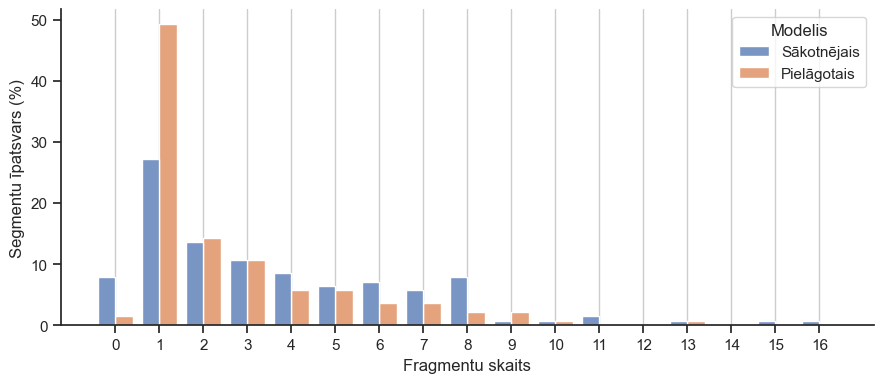

In [745]:
#plot_fragmentation_distribution(fragmentation_df)
# finetuned fragmentation distribution
#plot_fragmentation_distribution(fragmentation_df_finetuned)

plot_fragmentation_distribution_comparison(
    fragmentation_df,
    fragmentation_df_finetuned
)

### per exercise

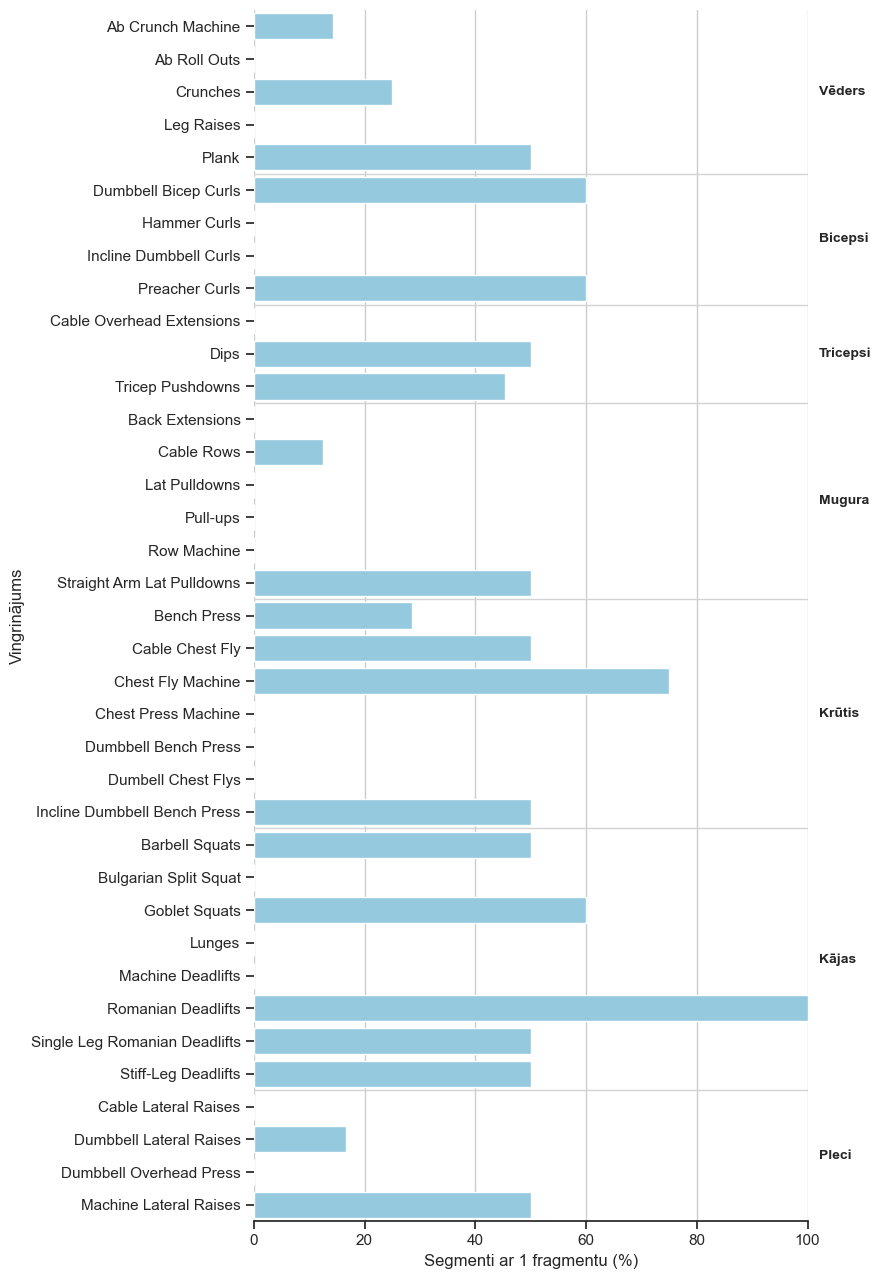

In [346]:
#plot_one_fragment_percentage_per_exercise(fragmentation_df)

In [728]:
#plot_fragmentation_per_exercise(fragmentation_df)
# finetuned fragmentation per exercise
#plot_fragmentation_per_exercise(fragmentation_df_finetuned)

### per session

In [746]:
display(calculate_fragmentation_per_session(fragmentation_df).style.format(decimal=",", precision=2))
# finetuned fragmentation per session
display(calculate_fragmentation_per_session(fragmentation_df_finetuned).style.format(decimal=",", precision=2))

,session,Vidējais,Mediānais,Q1,Q3,Maksimālais,Standartnovirze,Segmenti ar 1 fragmentu (%),Segmenti ar >=2 fragmentiem (%),Segmenti ar >=3 fragmentiem (%),Segmenti ar >=4 fragmentiem (%),Segmenti ar >=5 fragmentiem (%),Segmentu skaits,Nenoteikto segmentu skaits,Nenoteikti segmenti (%)
0,session_1776786984700,"2,05","1,00","1,00","2,75",8,"2,24","50,00","36,36","27,27","18,18","9,09",22,3,"13,64"
1,session_1776875240569,"4,38","4,50","2,75","6,00",9,"2,47","18,75","81,25","75,00","62,50","50,00",16,0,"0,00"
2,session_1776938763711,"2,94","2,00","1,00","4,50",8,"2,79","31,25","56,25","37,50","31,25","25,00",16,2,"12,50"
3,session_1777025558126,"6,06","6,00","1,75","8,00",16,"4,75","18,75","75,00","68,75","68,75","62,50",16,1,"6,25"
4,session_1777104300830,"2,50","2,00","1,75","3,00",8,"1,70","20,00","75,00","40,00","20,00","5,00",20,1,"5,00"
5,session_1777394359098,"4,16","4,00","1,00","6,00",13,"3,16","21,88","71,88","62,50","53,12","46,88",32,2,"6,25"
6,session_1777462103399,"3,39","2,50","1,00","5,50",11,"3,15","27,78","61,11","50,00","33,33","27,78",18,2,"11,11"


,session,Vidējais,Mediānais,Q1,Q3,Maksimālais,Standartnovirze,Segmenti ar 1 fragmentu (%),Segmenti ar >=2 fragmentiem (%),Segmenti ar >=3 fragmentiem (%),Segmenti ar >=4 fragmentiem (%),Segmenti ar >=5 fragmentiem (%),Segmentu skaits,Nenoteikto segmentu skaits,Nenoteikti segmenti (%)
0,session_1776786984700,"2,05","1,00","1,00","2,75",7,"1,86","59,09","36,36","27,27","18,18","13,64",22,1,"4,55"
1,session_1776875240569,"1,44","1,00","1,00","2,00",3,"0,73","68,75","31,25","12,50","0,00","0,00",16,0,"0,00"
2,session_1776938763711,"3,00","2,00","1,00","4,25",8,"2,34","37,50","62,50","43,75","31,25","25,00",16,0,"0,00"
3,session_1777025558126,"3,38","2,00","1,00","4,25",13,"3,46","43,75","56,25","37,50","37,50","25,00",16,0,"0,00"
4,session_1777104300830,"2,05","1,00","1,00","3,00",7,"1,90","60,00","35,00","30,00","15,00","15,00",20,1,"5,00"
5,session_1777394359098,"3,12","2,50","1,00","5,00",9,"2,52","46,88","53,12","50,00","37,50","28,12",32,0,"0,00"
6,session_1777462103399,"3,00","2,00","1,25","3,00",10,"2,68","27,78","72,22","33,33","22,22","16,67",18,0,"0,00"


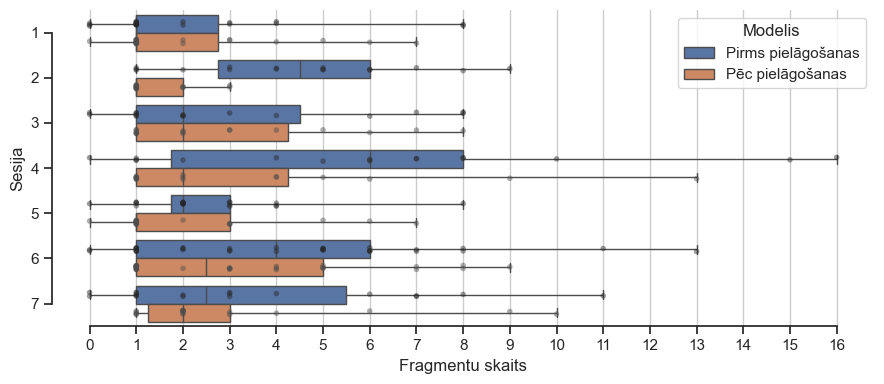

In [418]:
#plot_fragmentation_per_session(fragmentation_df)
# finetuned fragmentation per session
#plot_fragmentation_per_session(fragmentation_df_finetuned)

plot_fragmentation_per_session_comparison(
    fragmentation_df,
    fragmentation_df_finetuned
)

### Per muscle group

In [455]:
display(calculate_fragmentation_per_group(fragmentation_df).style.format(decimal=",", precision=2))
# finetuned fragmentation per group
display(calculate_fragmentation_per_group(fragmentation_df_finetuned).style.format(decimal=",", precision=2))

,group,Vidējais,Mediānais,Q1,Q3,Maksimālais,Standartnovirze,Segmenti ar 1 fragmentu (%),Segmenti ar >=2 fragmentiem (%),Segmenti ar >=3 fragmentiem (%),Segmenti ar >=4 fragmentiem (%),Segmenti ar >=5 fragmentiem (%),Segmentu skaits,Nenoteikto segmentu skaits,Nenoteikti segmenti (%)
0,Bicepsi,"4,19","2,50","1,00","7,25",11,"3,43","37,50","62,50","50,00","43,75","43,75",16,0,"0,00"
1,Krūtis,"2,52","2,00","1,00","4,00",7,"2,13","34,78","52,17","43,48","30,43","21,74",23,3,"13,04"
2,Kājas,"3,45","3,00","1,00","4,00",15,"3,21","37,93","62,07","51,72","34,48","20,69",29,0,"0,00"
3,Mugura,"4,32","4,50","2,00","5,75",16,"3,62","9,09","77,27","63,64","59,09","50,00",22,3,"13,64"
4,Pleci,"3,69","2,00","0,75","6,50",11,"3,68","12,50","62,50","43,75","43,75","37,50",16,4,"25,00"
5,Tricepsi,"2,62","2,00","1,00","4,00",7,"1,89","37,50","62,50","37,50","31,25","12,50",16,0,"0,00"
6,Vēders,"4,56","3,00","2,00","7,00",13,"3,55","16,67","77,78","66,67","44,44","44,44",18,1,"5,56"


,group,Vidējais,Mediānais,Q1,Q3,Maksimālais,Standartnovirze,Segmenti ar 1 fragmentu (%),Segmenti ar >=2 fragmentiem (%),Segmenti ar >=3 fragmentiem (%),Segmenti ar >=4 fragmentiem (%),Segmenti ar >=5 fragmentiem (%),Segmentu skaits,Nenoteikto segmentu skaits,Nenoteikti segmenti (%)
0,Bicepsi,"2,25","1,00","1,00","1,50",9,"2,49","75,00","25,00","25,00","18,75","18,75",16,0,"0,00"
1,Krūtis,"2,35","1,00","1,00","3,00",8,"2,17","52,17","43,48","30,43","21,74","21,74",23,1,"4,35"
2,Kājas,"2,79","2,00","1,00","5,00",7,"2,08","37,93","62,07","37,93","27,59","27,59",29,0,"0,00"
3,Mugura,"2,14","1,00","1,00","3,00",8,"1,73","54,55","45,45","31,82","18,18","4,55",22,0,"0,00"
4,Pleci,"3,81","3,50","1,75","4,75",9,"2,64","25,00","75,00","62,50","50,00","25,00",16,0,"0,00"
5,Tricepsi,"1,88","1,00","1,00","2,25",5,"1,26","56,25","43,75","25,00","12,50","6,25",16,0,"0,00"
6,Vēders,"3,11","1,00","1,00","3,00",13,"3,72","50,00","44,44","33,33","22,22","22,22",18,1,"5,56"


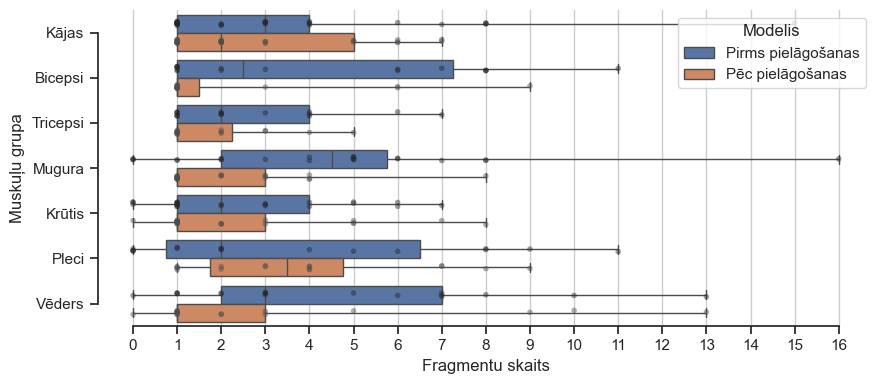

In [429]:
#plot_fragmentation_per_group(fragmentation_df)
# finetuned fragmentation per group
#plot_fragmentation_per_group(fragmentation_df_finetuned)
plot_fragmentation_per_group_comparison(
    fragmentation_df,
    fragmentation_df_finetuned
)

## Resting analysis

In [332]:
def calculate_false_rest_activations(
    rest_segments,
    prediction_col="prediction_binary"
):
    results = []

    for segment in rest_segments:
        preds = segment[prediction_col].fillna(0).astype(int)

        activation_starts = (
            (preds == 1) &
            (preds.shift(fill_value=0) == 0)
        )

        activation_count = activation_starts.sum()

        results.append({
            "session": segment["session"].iloc[0],
            "session_id": segment["session_id"].iloc[0],
            "false_activation_count": activation_count,
            "rest_duration_s":
                (segment["timestamp"].max() -
                 segment["timestamp"].min()) / 1000
        })

    return pd.DataFrame(results)

In [398]:
# Get rest segments
rest_segments = get_rest_segments(windows_df)

In [399]:
# Calculate false activations in rest segments
rest_activation_df = calculate_false_rest_activations(rest_segments)
display(rest_activation_df)

# finetuned false activations in rest segments
rest_activation_df_finetuned = calculate_false_rest_activations(rest_segments, prediction_col="prediction_finetuned_binary")
display(rest_activation_df_finetuned)

,session,session_id,false_activation_count,rest_duration_s
0,session_1776786984700,1,13,256.818
1,session_1776786984700,1,1,132.956
2,session_1776786984700,1,3,124.901
3,session_1776786984700,1,1,47.328
4,session_1776786984700,1,5,64.457
...,...,...,...,...
158,session_1777462103399,7,0,1.019
159,session_1777462103399,7,0,1.004
160,session_1777462103399,7,0,3.204
161,session_1777462103399,7,0,1.003


,session,session_id,false_activation_count,rest_duration_s
0,session_1776786984700,1,4,256.818
1,session_1776786984700,1,3,132.956
2,session_1776786984700,1,1,124.901
3,session_1776786984700,1,2,47.328
4,session_1776786984700,1,1,64.457
...,...,...,...,...
158,session_1777462103399,7,0,1.019
159,session_1777462103399,7,0,1.004
160,session_1777462103399,7,0,3.204
161,session_1777462103399,7,0,1.003


In [343]:
def calculate_rest_activation_statistics(rest_activation_df):
    durations = rest_activation_df["rest_duration_s"]

    fac = rest_activation_df["false_activation_count"]

    false_mask = fac > 0

    activations_per_min = (
        fac /
        (rest_activation_df["rest_duration_s"] / 60)
    )

    stats = {
        "Vidējais": fac.mean(),
        "Mediānais": fac.median(),
        "Q1": fac.quantile(0.25),
        "Q3": fac.quantile(0.75),
        "Standartnovirze": fac.std(),
        "Maksimālais": fac.max(),

        "Atpūtas segmenti bez kļūdainām aktivizācijām":
            (~false_mask).sum(),

        "Atpūtas segmenti ar kļūdainām aktivizācijām":
            false_mask.sum(),

        "Kļūdaino aktivizāciju īpatsvars (%)":
            false_mask.mean() * 100,

        "Vidējās aktivizācijas minūtē":
            activations_per_min.mean(),
        
        "Vidējais aktivizāciju ilgums (s)":
                rest_activation_df["rest_duration_s"].mean() / max(fac.mean(), 1),

        "Aktivizācijas ar ilgumu >= 1 s (%)":
            (durations >= 60).mean() * 100,
        
        "Aktivizācijas ar ilgumu >= 2 s (%)":
            (durations >= 120).mean() * 100,

        "Aktivizācijas ar ilgumu >= 3 s (%)":
            (durations >= 180).mean() * 100,
        
        "Aktivizācijas ar ilgumu >= 5 s (%)":
            (durations >= 300).mean() * 100,

        "Aktivizācijas ar ilgumu >= 10 s (%)":
            (durations >= 600).mean() * 100,
    }

    return pd.DataFrame([stats])

### Rest activation statistics

In [448]:
result_regular = calculate_rest_activation_statistics(rest_activation_df)
result_finetuned = calculate_rest_activation_statistics(rest_activation_df_finetuned)

combined = pd.concat([result_regular, result_finetuned], axis=0, keys=['Regular', 'Finetuned'])
display(combined.transpose().style.format(decimal=",", precision=2))

,Regular,Finetuned
,0,0
Vidējais,"7,02","5,00"
Mediānais,"4,00","3,00"
Q1,"1,00","1,00"
Q3,"9,00","7,00"
Standartnovirze,"8,52","6,25"
Maksimālais,"56,00","46,00"
Atpūtas segmenti bez kļūdainām aktivizācijām,"23,00","27,00"
Atpūtas segmenti ar kļūdainām aktivizācijām,"140,00","136,00"
Kļūdaino aktivizāciju īpatsvars (%),"85,89","83,44"


# Aizkave

## Methods

In [464]:
def prediction_runs_to_segments(
    windows_df,
    prediction_col="prediction_binary",
    timestamp_col="timestamp",
    session_col="session",
    session_id_col="session_id",
    max_gap_ms=3000
):
    """
    Converts window-level binary predictions into predicted exercise-state segments.

    Segment start:
        timestamp of the first positive prediction.

    Segment end:
        timestamp of the first negative prediction after the positive run,
        because that is when the system would leave the exercise state.

    If a session ends while still in exercise state, the segment ends at the last
    available prediction timestamp.
    """
    df = windows_df.copy()
    df = df.sort_values([session_col, timestamp_col])

    segments = []

    for (session, session_id), session_df in df.groupby([session_col, session_id_col]):
        session_df = session_df.sort_values(timestamp_col).copy()

        in_segment = False
        start_time = None
        last_time = None

        for _, row in session_df.iterrows():
            ts = row[timestamp_col]
            pred = int(row[prediction_col]) if not pd.isna(row[prediction_col]) else 0

            # If there is a large gap, close the segment at the last known timestamp.
            # We do not know what happened during the gap.
            if in_segment and last_time is not None and ts - last_time > max_gap_ms:
                segments.append({
                    "session": session,
                    "session_id": session_id,
                    "pred_start": start_time,
                    "pred_end": last_time,
                    "end_reason": "gap"
                })

                in_segment = False
                start_time = None

            if pred == 1 and not in_segment:
                start_time = ts
                in_segment = True

            elif pred == 0 and in_segment:
                segments.append({
                    "session": session,
                    "session_id": session_id,
                    "pred_start": start_time,
                    "pred_end": ts,
                    "end_reason": "first_negative"
                })

                in_segment = False
                start_time = None

            last_time = ts

        # If the session ends while still in exercise state,
        # we can only close at the last known timestamp.
        if in_segment:
            segments.append({
                "session": session,
                "session_id": session_id,
                "pred_start": start_time,
                "pred_end": last_time,
                "end_reason": "session_end"
            })

    return pd.DataFrame(segments)

In [649]:
def calculate_exercise_latency(
    windows_df,
    events_df,
    prediction_col="prediction_binary",
    timestamp_col="timestamp",
    max_gap_ms=3000
):
    """
    Calculates start and end latency for annotated exercise segments.

    A segment is counted as detected only if at least one predicted exercise
    segment overlaps the annotated exercise interval.

    Start latency:
        earliest overlapping predicted segment start - annotated start

    End latency:
        latest overlapping predicted segment end - annotated end
    """
    pred_segments = prediction_runs_to_segments(
        windows_df,
        prediction_col=prediction_col,
        timestamp_col=timestamp_col,
        max_gap_ms=max_gap_ms
    )

    results = []

    for i, event in events_df.iterrows():
        true_start = event["start_watch"]
        true_end = event["end_watch"]
        session = event["session"]
        session_id = event["session_id"]

        overlapping = pred_segments[
            (pred_segments["session"] == session) &
            (pred_segments["pred_end"] >= true_start) &
            (pred_segments["pred_start"] <= true_end)
        ].copy()

        if overlapping.empty:
            results.append({
                "segment_id": i + 1,
                "name": event["name"],
                "group": event["group"],
                "session": session,
                "session_id": session_id,
                "start_watch": true_start,
                "end_watch": true_end,

                "predicted_fragment_count": 0,

                "pred_start": np.nan,
                "pred_end": np.nan,
                "start_latency_ms": np.nan,
                "end_latency_ms": np.nan,
                "start_latency_sec": np.nan,
                "end_latency_sec": np.nan,
                "status": "Not Detected"
            })
            continue

        first_pred_segment = overlapping.sort_values("pred_start").iloc[0]
        last_pred_segment = overlapping.sort_values("pred_end").iloc[-1]

        pred_start = first_pred_segment["pred_start"]
        pred_end = last_pred_segment["pred_end"]

        start_latency_ms = pred_start - true_start
        end_latency_ms = pred_end - true_end

        results.append({
            "segment_id": i + 1,
            "name": event["name"],
            "group": event["group"],
            "session": session,
            "session_id": session_id,
            "start_watch": true_start,
            "end_watch": true_end,

            "predicted_fragment_count": len(overlapping),

            "pred_start": pred_start,
            "pred_end": pred_end,
            "start_latency_ms": start_latency_ms,
            "end_latency_ms": end_latency_ms,
            "start_latency_sec": start_latency_ms / 1000,
            "end_latency_sec": end_latency_ms / 1000,
            "status": "Detected"
        })

    return pd.DataFrame(results)

### Stats methods

In [475]:
def calculate_latency_statistics(latency_df, latency_col="start_latency_sec"):
    detected = latency_df[latency_df["status"] == "Detected"].copy()

    values = detected[latency_col].dropna()

    stats = {
        "Vidējais": values.mean(),
        "Mediāna": values.median(),
        "Standartnovirze": values.std(),
        "Minimums": values.min(),
        "Maksimums": values.max(),
        "1. kvartile": values.quantile(0.25),
        "3. kvartile": values.quantile(0.75),
        "P95": values.quantile(0.95),
        "Segmentu skaits": len(latency_df),
        "Detektēti segmenti": len(detected),
        "Nedetektēti segmenti": (latency_df["status"] != "Detected").sum(),
        "Detektēti segmenti (%)": (latency_df["status"] == "Detected").mean() * 100,
        "Aizkave ≤ 1 s (%)": (values.abs() <= 1).mean() * 100,
        "Aizkave ≤ 2 s (%)": (values.abs() <= 2).mean() * 100,
        "Aizkave ≤ 3 s (%)": (values.abs() <= 3).mean() * 100,
        "Aizkave ≤ 5 s (%)": (values.abs() <= 5).mean() * 100,
        "Aizkave ≤ 10 s (%)": (values.abs() <= 10).mean() * 100,
    }

    return pd.DataFrame([stats]).T

### plots

In [473]:
def plot_latency_statistics_combined(
    latency_df,
    latency_col="start_latency_sec",
    xlabel="Aizkave (s)",
    title=None,
    xlim=(-10, 10)
):
    detected = latency_df[latency_df["status"] == "Detected"].copy()

    if detected.empty:
        print("No detected events to plot.")
        return

    sns.set_theme(style="ticks")
    f, ax = plt.subplots(figsize=(10, 2))

    sns.boxplot(
        data=detected,
        x=latency_col,
        whis=[0, 100],
        width=.6,
        color="skyblue",
        ax=ax
    )

    sns.stripplot(
        data=detected,
        x=latency_col,
        size=4,
        color=".3",
        alpha=0.5,
        ax=ax
    )

    ax.axvline(0, linestyle="--", linewidth=1, color="black")

    ax.set(
        ylabel="Visi segmenti",
        xlabel=xlabel,
        title=title
    )

    ax.set_xlim(*xlim)
    ax.set_xticks(np.arange(xlim[0], xlim[1] + 1, 1))
    ax.xaxis.grid(True)

    sns.despine(trim=True)
    plt.tight_layout()
    plt.show()

In [760]:
def plot_latency_comparison_combined(
    latency_df_base,
    latency_df_finetuned,
    latency_col="start_latency_sec",
    xlabel="Aizkave (s)",
    ylabel="Modelis",
    title="Vingrošanas noteikšanas aizkaves salīdzinājums",
    xlim=(-5, 10)
):
    base = latency_df_base[latency_df_base["status"] == "Detected"].copy()
    finetuned = latency_df_finetuned[latency_df_finetuned["status"] == "Detected"].copy()

    base["Modelis"] = "Sākotnējais"
    finetuned["Modelis"] = "Pielāgotais"

    combined = pd.concat([base, finetuned], ignore_index=True)

    if combined.empty:
        print("No detected events to plot.")
        return

    sns.set_theme(style="ticks")

    f, ax = plt.subplots(figsize=(10, 3))

    sns.boxplot(
        data=combined,
        x=latency_col,
        y="Modelis",
        hue="Modelis",
        whis=[0, 100],
        width=.6,
        palette="vlag",
        legend=False,
        ax=ax
    )

    sns.stripplot(
        data=combined,
        x=latency_col,
        y="Modelis",
        size=4,
        color=".3",
        alpha=0.5,
        ax=ax
    )

    ax.axvline(0, linestyle="--", linewidth=1, color="black")

    ax.set_xlim(*xlim)
    ax.set_xticks(np.arange(xlim[0], xlim[1] + 1, 1))

    ax.xaxis.grid(True)

    ax.set(
        xlabel=xlabel,
        ylabel=ylabel,
        title=title
    )

    plt.ylabel(ylabel, rotation=90)

    sns.despine(trim=True, left=True)
    plt.tight_layout()
    plt.show()

In [494]:
def plot_latency_statistics_per_session(
    latency_df,
    latency_col="start_latency_sec",
    xlabel="Aizkave (s)",
    title="Vingrošanas noteikšanas aizkave pa sesijām",
    xlim=(-5, 10)
):
    detected = latency_df[latency_df["status"] == "Detected"].copy()

    if detected.empty:
        print("No detected events to plot.")
        return

    detected["session_id"] = detected["session_id"].astype(int)

    num_categories = detected["session_id"].nunique()
    dynamic_height = max(2, num_categories * 0.35)

    f, ax = plt.subplots(figsize=(8, dynamic_height))

    sns.boxplot(
        data=detected,
        x=latency_col,
        y="session_id",
        hue="session_id",
        whis=[0, 100],
        width=.6,
        palette="vlag",
        legend=False,
        orient="h",
        ax=ax
    )

    sns.stripplot(
        data=detected,
        x=latency_col,
        y="session_id",
        size=4,
        color=".3",
        alpha=0.6,
        orient="h",
        ax=ax
    )

    ax.axvline(0, linestyle="--", linewidth=1, color="black")

    ax.set_xlim(*xlim)
    ax.set_xticks(np.arange(xlim[0], xlim[1] + 1, 1))

    ax.xaxis.grid(True)
    ax.set(
        xlabel=xlabel,
        ylabel="Sesija",
        title=title
    )

    sns.despine(trim=True, left=True)
    plt.tight_layout()
    plt.show()

In [495]:
def plot_latency_statistics_per_group(
    latency_df,
    latency_col="start_latency_sec",
    xlabel="Aizkave (s)",
    title="Vingrošanas noteikšanas aizkave pa muskuļu grupām",
    xlim=(-5, 10),
    group_order=None
):
    detected = latency_df[latency_df["status"] == "Detected"].copy()

    if detected.empty:
        print("No detected events to plot.")
        return

    if group_order is not None:
        detected["group"] = pd.Categorical(
            detected["group"],
            categories=group_order,
            ordered=True
        )
        detected = detected.sort_values("group")

    num_categories = detected["group"].nunique()
    dynamic_height = max(2.5, num_categories * 0.45)

    f, ax = plt.subplots(figsize=(8, dynamic_height))

    sns.boxplot(
        data=detected,
        x=latency_col,
        y="group",
        hue="group",
        whis=[0, 100],
        width=.6,
        palette="vlag",
        legend=False,
        orient="h",
        ax=ax
    )

    sns.stripplot(
        data=detected,
        x=latency_col,
        y="group",
        size=4,
        color=".3",
        alpha=0.6,
        orient="h",
        ax=ax
    )

    ax.axvline(0, linestyle="--", linewidth=1, color="black")

    ax.set_xlim(*xlim)
    ax.set_xticks(np.arange(xlim[0], xlim[1] + 1, 1))

    ax.xaxis.grid(True)
    ax.set(
        xlabel=xlabel,
        ylabel="Muskuļu grupa",
        title=title
    )

    sns.despine(trim=True, left=True)
    plt.tight_layout()
    plt.show()

In [628]:
def plot_latency_comparison_per_session(
    latency_df_base,
    latency_df_finetuned,
    latency_col="start_latency_sec",
    xlabel="Aizkave (s)",
    title="Vingrošanas noteikšanas aizkaves salīdzinājums pa sesijām",
    xlim=(-5, 10)
):
    base = latency_df_base[
        latency_df_base["status"].str.lower() == "detected"
    ].copy()

    finetuned = latency_df_finetuned[
        latency_df_finetuned["status"].str.lower() == "detected"
    ].copy()

    if base.empty and finetuned.empty:
        print("No detected events to plot.")
        return

    base["Modelis"] = "Sākotnējais"
    finetuned["Modelis"] = "Pielāgotais"

    combined = pd.concat([base, finetuned], ignore_index=True)

    combined["session_id"] = combined["session_id"].astype(int)

    num_sessions = combined["session_id"].nunique()
    dynamic_height = max(2.5, num_sessions * 0.55)

    f, ax = plt.subplots(figsize=(9, dynamic_height))

    sns.boxplot(
        data=combined,
        x=latency_col,
        y="session_id",
        hue="Modelis",
        whis=[0, 100],
        width=.65,
        palette="vlag",
        orient="h",
        ax=ax
    )

    sns.stripplot(
        data=combined,
        x=latency_col,
        y="session_id",
        hue="Modelis",
        dodge=True,
        size=3,
        palette="dark:.3",
        alpha=0.45,
        orient="h",
        ax=ax
    )

    # Remove duplicated legend entries caused by boxplot + stripplot
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles[:2],
        labels[:2],
        title="Modelis",
        loc="best"
    )

    ax.axvline(0, linestyle="--", linewidth=1, color="black")

    ax.set_xlim(*xlim)
    ax.set_xticks(np.arange(xlim[0], xlim[1] + 1, 1))

    ax.xaxis.grid(True)

    ax.set(
        xlabel=xlabel,
        ylabel="Sesija",
        title=title
    )

    sns.despine(trim=True, left=True)
    plt.tight_layout()
    plt.show()

In [503]:
def plot_latency_statistics_per_group(
    latency_df,
    latency_col="start_latency_sec",
    xlabel="Aizkave (s)",
    title="Vingrošanas noteikšanas aizkave pa muskuļu grupām",
    xlim=(-5, 10),
    group_order=None
):
    detected = latency_df[latency_df["status"] == "Detected"].copy()

    if detected.empty:
        print("No detected events to plot.")
        return

    if group_order is not None:
        detected["group"] = pd.Categorical(
            detected["group"],
            categories=group_order,
            ordered=True
        )
        detected = detected.sort_values("group")

    num_categories = detected["group"].nunique()
    dynamic_height = max(2.5, num_categories * 0.45)

    f, ax = plt.subplots(figsize=(8, dynamic_height))

    sns.boxplot(
        data=detected,
        x=latency_col,
        y="group",
        hue="group",
        whis=[0, 100],
        width=.6,
        palette="vlag",
        legend=False,
        orient="h",
        ax=ax
    )

    sns.stripplot(
        data=detected,
        x=latency_col,
        y="group",
        size=4,
        color=".3",
        alpha=0.6,
        orient="h",
        ax=ax
    )

    ax.axvline(0, linestyle="--", linewidth=1, color="black")

    ax.set_xlim(*xlim)
    ax.set_xticks(np.arange(xlim[0], xlim[1] + 1, 1))

    ax.xaxis.grid(True)
    ax.set(
        xlabel=xlabel,
        ylabel="Muskuļu grupa",
        title=title
    )

    sns.despine(trim=True, left=True)
    plt.tight_layout()
    plt.show()

In [637]:
def plot_latency_comparison_per_group(
    latency_df_base,
    latency_df_finetuned,
    latency_col="start_latency_sec",
    xlabel="Aizkave (s)",
    title="Vingrošanas noteikšanas aizkaves salīdzinājums pa muskuļu grupām",
    xlim=(-5, 10),
    group_order=None
):
    base = latency_df_base[
        latency_df_base["status"].str.lower() == "detected"
    ].copy()

    finetuned = latency_df_finetuned[
        latency_df_finetuned["status"].str.lower() == "detected"
    ].copy()

    if base.empty and finetuned.empty:
        print("No detected events to plot.")
        return

    base["Modelis"] = "Sākotnējais"
    finetuned["Modelis"] = "Pielāgotais"

    combined = pd.concat([base, finetuned], ignore_index=True)

    if group_order is not None:
        combined["group"] = pd.Categorical(
            combined["group"],
            categories=group_order,
            ordered=True
        )
        combined = combined.sort_values("group")

    num_groups = combined["group"].nunique()
    dynamic_height = max(2.5, num_groups * 0.6)

    f, ax = plt.subplots(figsize=(9, dynamic_height))

    sns.boxplot(
        data=combined,
        x=latency_col,
        y="group",
        hue="Modelis",
        hue_order=["Sākotnējais", "Pielāgotais"],
        whis=[0, 100],
        width=.65,
        palette="vlag",
        orient="h",
        ax=ax
    )

    sns.stripplot(
        data=combined,
        x=latency_col,
        y="group",
        hue="Modelis",
        hue_order=["Sākotnējais", "Pielāgotais"],
        dodge=True,
        size=3,
        palette="dark:.3",
        alpha=0.45,
        orient="h",
        ax=ax
    )

    # Remove duplicated legend entries caused by boxplot + stripplot
    handles, labels = ax.get_legend_handles_labels()

    ax.legend(
        handles[:2],
        labels[:2],
        title="Modelis",
        loc="best"
    )

    ax.axvline(0, linestyle="--", linewidth=1, color="black")

    ax.set_xlim(*xlim)
    ax.set_xticks(np.arange(xlim[0], xlim[1] + 1, 1))

    ax.xaxis.grid(True)

    ax.set(
        xlabel=xlabel,
        ylabel="Muskuļu grupa",
        title=title
    )

    sns.despine(trim=True, left=True)
    plt.tight_layout()
    plt.show()

In [472]:
latency_df = calculate_exercise_latency(
    windows_df,
    events_df,
    prediction_col="prediction_binary"
)

latency_df_finetuned = calculate_exercise_latency(
    windows_df,
    events_df,
    prediction_col="prediction_finetuned_binary"
)

display(latency_df_finetuned)

,segment_id,name,group,session,session_id,start_watch,end_watch,pred_start,pred_end,start_latency_ms,end_latency_ms,start_latency_sec,end_latency_sec,status
0,1,Goblet Squats,Kājas,session_1776786984700,1,1776787245500,1776787285953,1.776787e+12,1.776787e+12,631.0,474.0,0.631,0.474,Detected
1,2,Goblet Squats,Kājas,session_1776786984700,1,1776787419901,1776787442407,1.776787e+12,1.776787e+12,2506.0,-863.0,2.506,-0.863,Detected
2,3,Dumbbell Bicep Curls,Bicepsi,session_1776786984700,1,1776787568132,1776787595361,1.776788e+12,1.776788e+12,327.0,3323.0,0.327,3.323,Detected
3,4,Dumbbell Bicep Curls,Bicepsi,session_1776786984700,1,1776787643532,1776787669601,1.776788e+12,1.776788e+12,1471.0,1584.0,1.471,1.584,Detected
4,5,Dumbbell Bicep Curls,Bicepsi,session_1776786984700,1,1776787734931,1776787755462,1.776788e+12,1.776788e+12,715.0,-683.0,0.715,-0.683,Detected
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135,136,Dumbbell Overhead Press,Pleci,session_1777462103399,7,1777466816373,1777466836962,1.777467e+12,1.777467e+12,-10435.0,-861.0,-10.435,-0.861,Detected
136,137,Dumbbell Overhead Press,Pleci,session_1777462103399,7,1777466999503,1777467023680,1.777467e+12,1.777467e+12,-3645.0,-670.0,-3.645,-0.670,Detected
137,138,Leg Raises,Vēders,session_1777462103399,7,1777467487399,1777467512637,1.777467e+12,1.777468e+12,-2049.0,-1160.0,-2.049,-1.160,Detected
138,139,Leg Raises,Vēders,session_1777462103399,7,1777468015678,1777468034084,1.777468e+12,1.777468e+12,292.0,-27.0,0.292,-0.027,Detected


## Stats

In [493]:
calculated_latency_stats = calculate_latency_statistics(latency_df, latency_col="start_latency_sec").transpose()
calculated_latency_stats_finetuned = calculate_latency_statistics(latency_df_finetuned, latency_col="start_latency_sec").transpose()

combined_latency_stats = pd.concat(
    [calculated_latency_stats, calculated_latency_stats_finetuned],
    axis=0,
    keys=["Regular", "Finetuned"]
).transpose()

print("Start latency statistics:")

display(combined_latency_stats.style.format(decimal=",", precision=2))

Start latency statistics:


,Regular,Finetuned
,0,0
Vidējais,"2,16","-0,12"
Mediāna,"0,95","0,72"
Standartnovirze,"6,58","5,58"
Minimums,"-25,06","-41,16"
Maksimums,"42,10","25,31"
1. kvartile,"0,08","-0,73"
3. kvartile,"2,50","1,59"
P95,"11,81","3,04"
Segmentu skaits,"140,00","140,00"


In [492]:
calculated_latency_stats = calculate_latency_statistics(latency_df, latency_col="end_latency_sec").transpose()
calculated_latency_stats_finetuned = calculate_latency_statistics(latency_df_finetuned, latency_col="end_latency_sec").transpose()

combined_latency_stats = pd.concat(
    [calculated_latency_stats, calculated_latency_stats_finetuned],
    axis=0,
    keys=["Regular", "Finetuned"]
).transpose()

print("End Latency Statistics:")

display(combined_latency_stats.style.format(decimal=",", precision=2))

End Latency Statistics:


,Regular,Finetuned
,0,0
Vidējais,"-1,66","-0,42"
Mediāna,"-0,24","-0,00"
Standartnovirze,"5,71","2,58"
Minimums,"-40,16","-13,73"
Maksimums,"4,34","3,39"
1. kvartile,"-1,73","-0,91"
3. kvartile,"0,57","0,76"
P95,"2,79","2,94"
Segmentu skaits,"140,00","140,00"


## Plot 

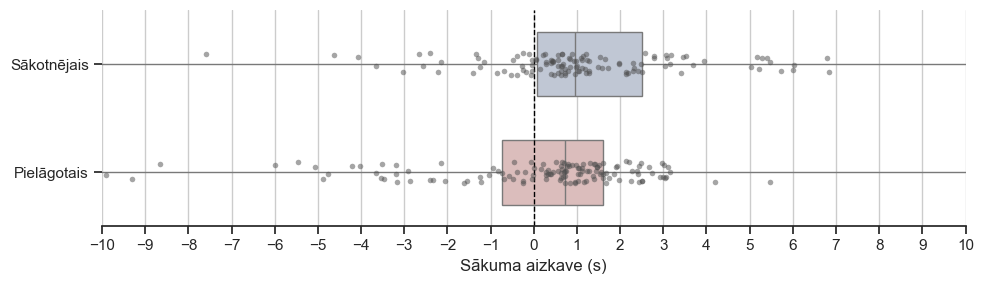

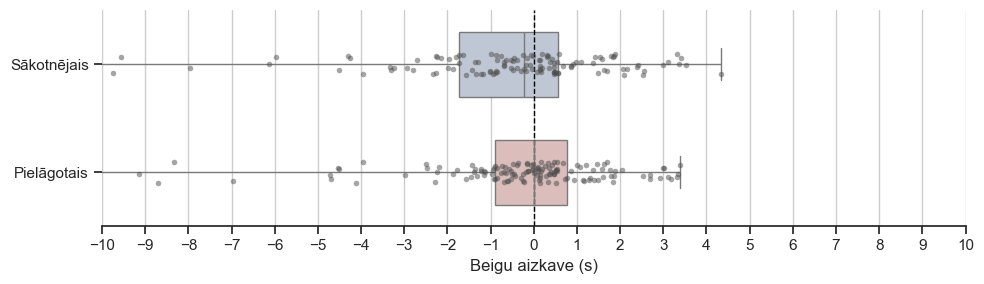

In [762]:
plot_latency_comparison_combined(
    latency_df,
    latency_df_finetuned,
    latency_col="start_latency_sec",
    xlabel="Sākuma aizkave (s)",
    ylabel="",
    title="",
    xlim=(-10, 10)
)

plot_latency_comparison_combined(
    latency_df,
    latency_df_finetuned,
    latency_col="end_latency_sec",
    xlabel="Beigu aizkave (s)",
    ylabel="",
    title="",
    xlim=(-10, 10)
)

## Plot per session

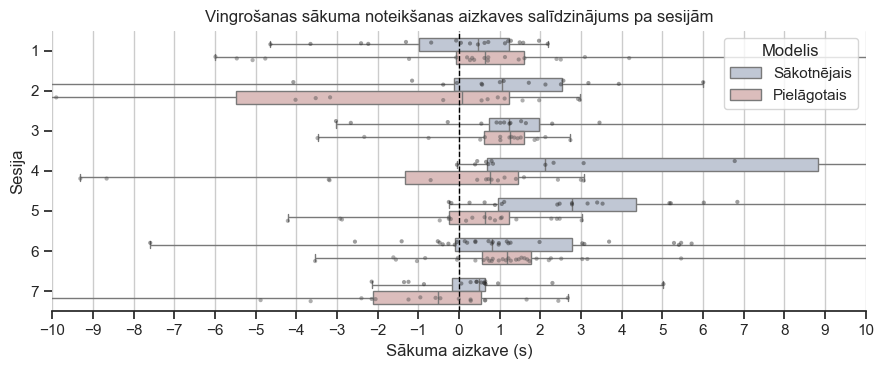

In [629]:
plot_latency_comparison_per_session(
    latency_df,
    latency_df_finetuned,
    latency_col="start_latency_sec",
    xlabel="Sākuma aizkave (s)",
    title="Vingrošanas sākuma noteikšanas aizkaves salīdzinājums pa sesijām",
    xlim=(-10, 10)
)

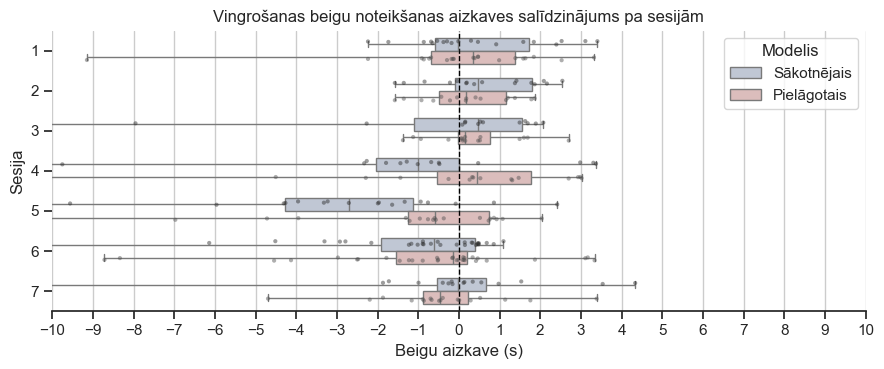

In [630]:
plot_latency_comparison_per_session(
    latency_df,
    latency_df_finetuned,
    latency_col="end_latency_sec",
    xlabel="Beigu aizkave (s)",
    title="Vingrošanas beigu noteikšanas aizkaves salīdzinājums pa sesijām",
    xlim=(-10, 10)
)

## Plot per group

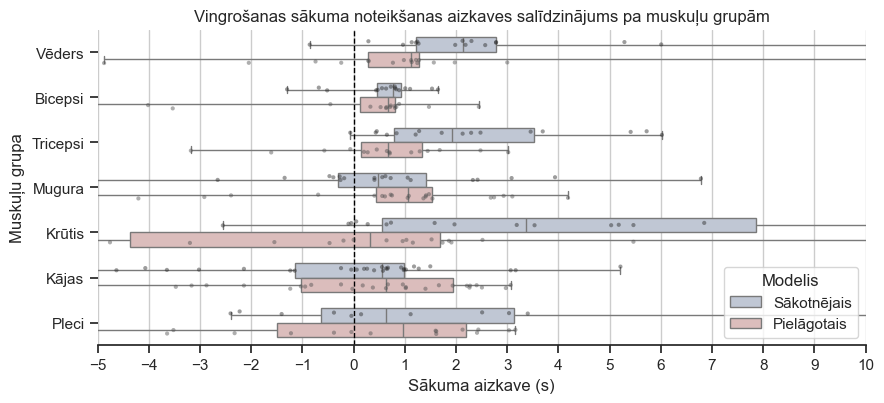

In [640]:
plot_latency_comparison_per_group(
    latency_df,
    latency_df_finetuned,
    latency_col="start_latency_sec",
    xlabel="Sākuma aizkave (s)",
    title="Vingrošanas sākuma noteikšanas aizkaves salīdzinājums pa muskuļu grupām",
    xlim=(-5, 10),
    group_order=GROUP_ORDER
)

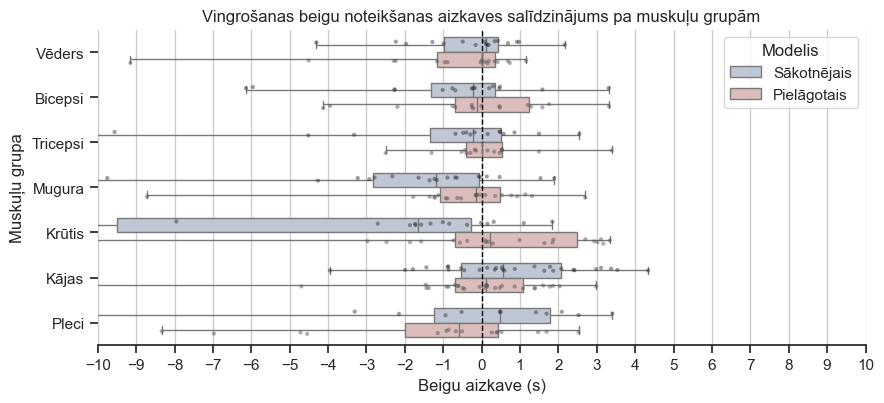

In [638]:
plot_latency_comparison_per_group(
    latency_df,
    latency_df_finetuned,
    latency_col="end_latency_sec",
    xlabel="Beigu aizkave (s)",
    title="Vingrošanas beigu noteikšanas aizkaves salīdzinājums pa muskuļu grupām",
    xlim=(-10, 10),
    group_order=GROUP_ORDER
)

# RecoFit style metrics

## Methods

In [655]:
def count_good_single_fragment_segments(
    latency_df,
    thresholds=(2, 5),
    start_col="start_latency_sec",
    end_col="end_latency_sec",
    fragment_col="predicted_fragment_count"
):
    rows = []

    total_segments = len(latency_df)

    detected = latency_df[
        latency_df["status"].str.lower() == "detected"
    ].copy()

    for threshold in thresholds:
        good = detected[
            (detected[fragment_col] == 1) &
            (detected[start_col].abs() <= threshold) &
            (detected[end_col].abs() <= threshold)
        ]

        rows.append({
            "Robeža": f"±{threshold}s",
            "Segmenti kopā": total_segments,
            "Detektēti segmenti": len(detected),
            "Segmenti ar vienu fragmentu robežās": len(good),
            "Īpatsvars no visiem segmentiem (%)": len(good) / total_segments * 100,
            "Īpatsvars no detektētajiem segmentiem (%)": len(good) / len(detected) * 100 if len(detected) > 0 else 0
        })

    return pd.DataFrame(rows)

def good_single_fragment_stats_by(
    latency_df,
    by,
    thresholds=(2, 5),
    start_col="start_latency_sec",
    end_col="end_latency_sec",
    fragment_col="predicted_fragment_count"
):
    rows = []

    df = latency_df.copy()
    df["is_detected"] = df["status"].str.lower() == "detected"

    for group_value, group_df in df.groupby(by, dropna=False):
        total_segments = len(group_df)
        detected = group_df[group_df["is_detected"]].copy()

        for threshold in thresholds:
            good = detected[
                (detected[fragment_col] == 1) &
                (detected[start_col].abs() <= threshold) &
                (detected[end_col].abs() <= threshold)
            ]

            rows.append({
                by: group_value,
                "Robeža": f"±{threshold}s",
                "Segmenti kopā": total_segments,
                "Detektēti segmenti": len(detected),
                "Labi segmenti": len(good),
                "Īpatsvars no visiem segmentiem (%)": (
                    len(good) / total_segments * 100
                    if total_segments > 0 else 0
                ),
                "Īpatsvars no detektētajiem segmentiem (%)": (
                    len(good) / len(detected) * 100
                    if len(detected) > 0 else 0
                )
            })

    return pd.DataFrame(rows)

# Stats

In [652]:
latency_df = calculate_exercise_latency(
    windows_df,
    events_df,
    prediction_col="prediction_binary"
)

latency_df_finetuned = calculate_exercise_latency(
    windows_df,
    events_df,
    prediction_col="prediction_finetuned_binary"
)

In [653]:
single_fragment_latency_stats = count_good_single_fragment_segments(
    latency_df,
    thresholds=(2, 5)
)

display(single_fragment_latency_stats.style.format(decimal=",", precision=2))

single_fragment_latency_stats_finetuned = count_good_single_fragment_segments(
    latency_df_finetuned,
    thresholds=(2, 5)
)

display(single_fragment_latency_stats_finetuned.style.format(decimal=",", precision=2))

,Robeža,Segmenti kopā,Detektēti segmenti,Segmenti ar vienu fragmentu robežās,Īpatsvars no visiem segmentiem (%),Īpatsvars no detektētajiem segmentiem (%)
0,±2s,140,130,16,"11,43","12,31"
1,±5s,140,130,24,"17,14","18,46"


,Robeža,Segmenti kopā,Detektēti segmenti,Segmenti ar vienu fragmentu robežās,Īpatsvars no visiem segmentiem (%),Īpatsvars no detektētajiem segmentiem (%)
0,±2s,140,138,39,"27,86","28,26"
1,±5s,140,138,58,"41,43","42,03"


In [666]:
single_fragment_per_session = good_single_fragment_stats_by(
    latency_df,
    by="group",
    thresholds=(5,)
)

display(single_fragment_per_session.style.format(decimal=",", precision=2))

single_fragment_per_session_finetuned = good_single_fragment_stats_by(
    latency_df_finetuned,
    by="group",
    thresholds=(5,)
)

display(single_fragment_per_session_finetuned.style.format(decimal=",", precision=2))

,group,Robeža,Segmenti kopā,Detektēti segmenti,Labi segmenti,Īpatsvars no visiem segmentiem (%),Īpatsvars no detektētajiem segmentiem (%)
0,Bicepsi,±5s,16,16,5,"31,25","31,25"
1,Krūtis,±5s,23,20,2,"8,70","10,00"
2,Kājas,±5s,29,29,8,"27,59","27,59"
3,Mugura,±5s,22,20,1,"4,55","5,00"
4,Pleci,±5s,16,12,0,"0,00","0,00"
5,Tricepsi,±5s,16,16,5,"31,25","31,25"
6,Vēders,±5s,18,17,3,"16,67","17,65"


,group,Robeža,Segmenti kopā,Detektēti segmenti,Labi segmenti,Īpatsvars no visiem segmentiem (%),Īpatsvars no detektētajiem segmentiem (%)
0,Bicepsi,±5s,16,16,11,"68,75","68,75"
1,Krūtis,±5s,23,22,6,"26,09","27,27"
2,Kājas,±5s,29,29,9,"31,03","31,03"
3,Mugura,±5s,22,22,11,"50,00","50,00"
4,Pleci,±5s,16,16,3,"18,75","18,75"
5,Tricepsi,±5s,16,16,9,"56,25","56,25"
6,Vēders,±5s,18,17,9,"50,00","52,94"
